### Part A: Single Day Local Volatility Pricer

Part A of this notebook implements the following task for a single day: September 30, 2025
- download SPX option contracts data using Polygon API
- build a daily file with reak bid/ask/mid prices from NBBO quotes
- build call/put pairs and compute forwards using call-put parity
- build a dividend yield curve q(T) and find the implied volatilies
- find the arbitrage-free price surface using a practical Andreasen-Huge style fit (Model A)
- obtain the Dupire local volatilty surface from the fitted price surface
- run diagonistics and see if the results make sense
- substitute the local volatility and solve the PDE using Crank-Nicolson algorithm for the option prices (Model B)
- pricing diagonostics and model comparison (Black-Scholes vs Arbitrage-free price surface vs Local volatility PDE)
- plot and compare the Greeks for Local volatilty PDE vs Black-Scholes



Step 1: Obtain the daily NBBO quotes data using Polygon API

In [1]:
# ensure that the Polygon key is loaded from the .env file
from dotenv import load_dotenv
import os

load_dotenv()
POLYGON_API_KEY = os.getenv("POLYGON_API_KEY")
print (f"Polygon API Key: {POLYGON_API_KEY}")

Polygon API Key: x1DYEDXbVnbKq7pJRgsMr6Tx6Lf9bTOW


In [2]:
# suppress warnings
import warnings
warnings.filterwarnings("ignore")

In [3]:
# sanity check: can we talk to polygon.io?

import os, requests
from dotenv import load_dotenv

API_KEY = os.getenv("POLYGON_API_KEY")
BASE_URL = "https://api.polygon.io"

# lightweight ping: list. a couple of SPX option contracts for a given date

params = {
    "underlying_ticker": "SPX",
    "as_of": "2025-09-30",
    "limit": 5,
    "apiKey": API_KEY
}

url = f"{BASE_URL}/v3/reference/options/contracts"
r = requests.get(url, params=params, timeout=30)
r.raise_for_status()
data = r.json()

print("count:", len(data.get("results", [])))
for x in data.get("results", [])[:]:
    print(x["ticker"])

count: 5
O:SPX251017C00200000
O:SPX251017C00400000
O:SPX251017C00600000
O:SPX251017C00800000
O:SPX251017C01000000


In [4]:
# list the option chain (contracts) for a day

import  pandas as pd
from urllib.parse import urlparse, parse_qs, urlencode, urlunparse

API_KEY = os.getenv("POLYGON_API_KEY")

# helper to add apiKey to next_url pages
def _with_api_key(url: str) -> str:
    """Ensure apiKey is present in the URL (for Polygon next_url pages)"""
    parsed = urlparse(url)
    query = parse_qs(parsed.query)
    query["apiKey"] = API_KEY
    parsed = parsed._replace(query=urlencode(query, doseq=True))
    return urlunparse(parsed)

# paginate helper to follow next_url links
def paginate(url: str, params: dict):
    """Call first page with params; follow next_url pages adding the apiKey"""
    params = dict(params or {})
    params["apiKey"] = API_KEY
    r = requests.get(url, params=params, timeout=30)
    r.raise_for_status()
    data = r.json()
    yield data

    while data.get("next_url"):
        nxt = _with_api_key(data["next_url"])
        r = requests.get(nxt, timeout=30)
        r.raise_for_status()
        data = r.json()
        yield data
                        
# main function to list SPX option contracts for a given date
def list_spx_contracts(asof_iso) -> pd.DataFrame:
    """Contracts for SPX as of date (includes SPX and SPXW)"""
    url = f"{BASE_URL}/v3/reference/options/contracts"
    params = {
        "underlying_ticker": "SPX",
        "as_of": asof_iso,
        "expired": "false",
        "limit": 1000,
        "order": "asc",
        "sort": "expiration_date",
    }
    rows = []
    for page in paginate(url, params):
        rows += page.get("results", [])
    df = pd.DataFrame(rows)
    if df.empty:
        return df

    keep = ["ticker", "expiration_date", "strike_price"]
    for k in keep:
        if k not in df.columns:
            df[k] = None

    # add tenor_days window for a cleaner subset
    asof = pd.to_datetime(asof_iso)
    exp = pd.to_datetime(df["expiration_date"], errors="coerce")        
    df["tenor_days"] = (exp - asof).dt.days

    # keep reasonable expiries (2...365 days)
    df = df[(df["tenor_days"] >= 2) & (df["tenor_days"] <= 365)].copy()
    return df.sort_values(["expiration_date", "strike_price"])


In [5]:
# test that list_spx_contracts gives expected output
df = list_spx_contracts("2025-09-30")
print("total returned:", len(df))
print(df[["ticker","expiration_date","strike_price"]].head(10))

total returned: 21648
                     ticker expiration_date  strike_price
1500  O:SPXW251002C02600000      2025-10-02          2600
1708  O:SPXW251002P02600000      2025-10-02          2600
1501  O:SPXW251002C02800000      2025-10-02          2800
1709  O:SPXW251002P02800000      2025-10-02          2800
1502  O:SPXW251002C03000000      2025-10-02          3000
1710  O:SPXW251002P03000000      2025-10-02          3000
1503  O:SPXW251002C03200000      2025-10-02          3200
1711  O:SPXW251002P03200000      2025-10-02          3200
1504  O:SPXW251002C03400000      2025-10-02          3400
1712  O:SPXW251002P03400000      2025-10-02          3400


In [6]:
# get the SPX close for a given date
def spx_close_on(asof_iso: str) -> float:
    """
    Get I:SPX close for a given calendar date.
    Tries minute bars for that day, falls back to daily bars.
    """
    # minute bars for the day
    url = f"{BASE_URL}/v2/aggs/ticker/I:SPX/range/1/minute/{asof_iso}/{asof_iso}"
    params = {"apiKey": API_KEY, "adjusted": "false", "limit": 50000}
    r = requests.get(url, params=params, timeout=30)

    if r.status_code == 200:
        j = r.json()
        if j.get("results"):
            return float(j["results"][-1]["c"])
    elif r.status_code not in {400, 404}:
        r.raise_for_status()

    # daily bars for a single day window
    url_day = f"{BASE_URL}/v2/aggs/ticker/I:SPX/range/1/day/{asof_iso}/{asof_iso}"
    r = requests.get(url_day, params=params, timeout=30)

    if r.status_code == 200:
        j = r.json()
        if j.get("results"):
            return float(j["results"][-1]["c"])
    else:
         # Surface a helpful message
        try:
            err = r.json()
        except Exception:
            err = {"message": r.text[:200]}
        raise requests.HTTPError(f"I:SPX daily aggregates failed ({r.status_code}): {err}")

In [7]:
# decode OCC tickets (expiry, C/P, strike)

import re

def decode_occ_ticket(ticket: str):
    """
    OCC format: ROOT + YYMMDD + C?P + 8-digit strike (3 implied decimals)
    e.g. O:SPXW250930C01200000
    """

    sym = ticket.split(":")[-1]  # strip prefix if present
    m = re.search(r"(\d{6})([CP])(\d{8})$", sym)
    if not m:
        return None
    
    date6, cp, strike8 = m.groups()
    expiry = f"20{date6[:2]}-{date6[2:4]}-{date6[4:6]}"
    strike = int(strike8) / 1000.0
    return {
        "expiry": expiry,
        "cp": cp,
        "K": strike
    }

In [8]:
# test decode_occ_ticket
ex = "O:SPXW251002C02600000"
res = decode_occ_ticket(ex)
print(f"Decoded {ex} as {res}")

Decoded O:SPXW251002C02600000 as {'expiry': '2025-10-02', 'cp': 'C', 'K': 2600.0}


In [9]:
# make a resilient HTTP session (reuse + retries)
import os, requests
from urllib3.util.retry import Retry
from requests.adapters import HTTPAdapter

def make_session(total=5, backoff=0.4, connect=5, read=30) -> requests.Session:
    """
    Reusable session with retry on transient network/5xx/timeouts.
    """
    s = requests.Session()
    retry = Retry(
        total=total,
        connect=total,
        read=total,
        backoff_factor=backoff,
        status_forcelist=(429, 500, 502, 503, 504),
        allowed_methods=frozenset(["GET"])
    )
    adapter = HTTPAdapter(max_retries=retry, pool_connections=100, pool_maxsize=100)
    s.mount("https://", adapter)
    s.mount("http://", adapter)
    # store default timeouts (connect, read) on the session
    s.request = _with_timeout(s.request, (connect, read))
    return s

def _with_timeout(request_fn, timeout_tuple):
    def wrapped(method, url, **kwargs):
        kwargs.setdefault("timeout", timeout_tuple)
        return request_fn(method, url, **kwargs)
    return wrapped


In [10]:
# add a quote fetcher

_session = make_session()

def last_nbbo_for_day(occ: str, asof_iso: str):
    """
    Get the last NBBO quote for an OCC on a given calendar date via a single call.
    Use order = desc, limit =1 so we don't paginate a whole day's quotes.
    """
    url = f"{BASE_URL}/v3/quotes/{occ}"
    rows = []
    params = {
        "apiKey": API_KEY,
        "timestamp": asof_iso,
        "sort": "sip_timestamp",
        "order": "desc",
        "limit": 1,
    }
    r = _session.get(url, params=params)
    r.raise_for_status()
    res = (r.json() or {}).get("results") or []
    if not res:
        return None

    q = res[0]
    bid = q.get("bid_price")
    ask = q.get("ask_price")
    if bid is None or ask is None or bid <= 0.0 or ask <= 0.0 or ask < bid:
        # Rare: if the very kast us crossed, ask for few more and scan
        params["limit"] = 100
        r = _session.get(url, params=params)
        r.raise_for_status()
        res = (r.json() or {}).get("results") or []
        for q in res:
            bid = q.get("bid_price")
            ask = q.get("ask_price")
            if bid is not None and ask is not None and bid > 0.0 and ask > 0.0 and ask >= bid:
                return {
                    "bid": float(bid),
                    "ask": float(ask),
                    "mid": 0.5*(bid + ask),
                    "sip_ts": int(q.get("sip_timestamp", 0))
                    }
        return None

    return {
        "bid": float(bid),
        "ask": float(ask),
        "mid": 0.5*(bid + ask),
        "sip_ts": int(q.get("sip_timestamp", 0))
    }

In [11]:
# build the daily quotes file
import time
from pathlib import Path

def build_day_from_quotes(asof_iso: str, out_csv: str, 
                          max_expiries: int = 12, strikes_per_exp: int = 60,
                          sleep_ms: int = 20, max_contracts_hard: int = 2000,
                          moneyness_band=(0.5, 1.6)):
    """
    Builds a daily file with *real* bid/ask/mid from NBBO quotes.
    Columns: asof, timestamp, cp, K, T, bid, ask, mid, S, expiry, symbol
    """

    chain = list_spx_contracts(asof_iso)
    if chain.empty:
        raise SystemExit("No SPX contracts returned for that date.")
    
    # Spot from Indices Starter
    S = spx_close_on(asof_iso)
    asof = pd.to_datetime(asof_iso)

    # Filter to a decent strike band to keep volume up and quotes meaningful
    lo = moneyness_band[0] * S
    hi = moneyness_band[1] * S
    chain = chain[(chain["strike_price"] >= lo) & (chain["strike_price"] <= hi)].copy()

    # Keep up to N expiries and K strikes nearest ATM per expiry
    exps = sorted(chain["expiration_date"].dropna().unique().tolist())[:max_expiries]
    chain = chain[chain["expiration_date"].isin(exps)].copy()
    chain["dist"] = (chain["strike_price"] - S).abs()
    chain = chain.sort_values(["expiration_date", "dist"]).groupby("expiration_date").head(strikes_per_exp)
    chain = chain.drop(columns=["dist"])

    # hard cap to avoid accidental huge runs
    if len(chain) > max_contracts_hard:
        chain = chain.head(max_contracts_hard).copy()

    records = []
    misses = 0
    for occ in chain["ticker"]:
        nbbo = None
        try:
            nbbo = last_nbbo_for_day(occ, asof_iso)
        except requests.exceptions.ReadTimeout:
            # extremely rare with the retrying session but continue if it happens
            misses += 1
            continue

        time.sleep(sleep_ms / 1000.0)  # rate limit

        if not nbbo:
            misses += 1
            continue

        info = decode_occ_ticket(occ)
        if not info:
            continue

        expiry = pd.to_datetime(info["expiry"])
        T = max((expiry - asof).days, 0) / 365.0

        records.append({
            "asof": asof.strftime("%Y%m%d"),
            "timestamp": asof_iso + " 15:59:59", # near market close
            "cp": info["cp"],
            "K": float(info["K"]),
            "T": float(T),
            "bid": float(nbbo["bid"]),
            "ask": float(nbbo["ask"]),
            "mid": float(nbbo["mid"]),
            "S": float(S),
            "expiry": info["expiry"],
            "symbol": "SPX",
        })

    df_out = pd.DataFrame(records).sort_values(["expiry", "K", "cp"])
    if df_out.empty:
        raise SystemExit(f"No quotes gathered. Misses: {misses}. Try widening bands or more expiries/strikes.")
    Path(out_csv).parent.mkdir(parents=True, exist_ok=True)
    df_out.to_csv(out_csv, index=False)
    print(f"Wrote {len(df_out)} rows to {out_csv}  (misses={misses})")

    return df_out


In [12]:
ASOF = "2025-09-30"
OUT = f"data/quotes/{ASOF.replace('-','')}_quotes.csv"
build_day_from_quotes(ASOF, OUT)

Wrote 720 rows to data/quotes/20250930_quotes.csv  (misses=0)


,asof,timestamp,cp,K,T,bid,ask,mid,S,expiry,symbol
58,20250930,2025-09-30 15:59:59,C,6615.0,0.005479,57.0,78.1,67.55,6688.46,2025-10-02,SPX
59,20250930,2025-09-30 15:59:59,P,6615.0,0.005479,7.9,8.4,8.15,6688.46,2025-10-02,SPX
54,20250930,2025-09-30 15:59:59,C,6620.0,0.005479,52.7,74.5,63.60,6688.46,2025-10-02,SPX
55,20250930,2025-09-30 15:59:59,P,6620.0,0.005479,8.5,9.0,8.75,6688.46,2025-10-02,SPX
50,20250930,2025-09-30 15:59:59,C,6625.0,0.005479,48.0,69.3,58.65,6688.46,2025-10-02,SPX
...,...,...,...,...,...,...,...,...,...,...,...
711,20250930,2025-09-30 15:59:59,P,6720.0,0.046575,76.4,94.8,85.60,6688.46,2025-10-17,SPX
716,20250930,2025-09-30 15:59:59,C,6725.0,0.046575,47.0,48.3,47.65,6688.46,2025-10-17,SPX
718,20250930,2025-09-30 15:59:59,C,6725.0,0.046575,48.6,49.4,49.00,6688.46,2025-10-17,SPX
717,20250930,2025-09-30 15:59:59,P,6725.0,0.046575,72.0,88.3,80.15,6688.46,2025-10-17,SPX


Step 2: Compute forwards from parity (+ spot proxy and checks)

In [13]:
# build fowards

CSV_IN = f"data/quotes/{ASOF.replace('-','')}_quotes.csv"
OUT_DIR = Path("artifacts")
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [14]:
import numpy as np

# helper to compute tenor from expiry
def _tenor_from_expiry(expiry_str: str, asof_str: str) -> float:
    e = pd.to_datetime(expiry_str); a = pd.to_datetime(asof_str)
    return max((e - a).days, 0) / 365.0

# make pairs on expiry and K
def make_pairs_on_expiryK(df: pd.DataFrame, asof: str) -> pd.DataFrame:
    """
    Take rows with columns: ['cp', 'K', 'expiry', 'mid'] and return C/P pairs
    matched on (expiry, K, T).
    """
    base = df[["cp","K","expiry","mid"]].copy()
    base["T"] = base["expiry"].apply(lambda x: _tenor_from_expiry(x, asof))
    call = base[base["cp"]=="C"].drop(columns=["cp"]).rename(columns={"mid":"C"})
    put  = base[base["cp"]=="P"].drop(columns=["cp"]).rename(columns={"mid":"P"})
    return pd.merge(call, put, on=["expiry","K","T"], how="inner")

In [15]:
# compute forwards from parity
def parity_forward(pairs: pd.DataFrame, r: float = 0.0) -> pd.DataFrame:
    """
    F = K + e^{rT}(C - P). Use r=0 for now.
    """
    out = pairs.copy()
    out["F"] = out["K"] + np.exp(r * out["T"]) * (out["C"] - out["P"])
    return out

In [16]:
# choose robust spot proxy from forwards
def robust_S_from_F(Fdf: pd.DataFrame, tmin_days=7, tmax_days=90) -> float:
    """
    Choose a robust "spot" proxy as the median forward for short expiries.
    Falls back to all expiries if short window is empty
    """
    short = Fdf[(Fdf["T"] >= tmin_days/365) & (Fdf["T"] <= tmax_days/365)]
    if not short.empty:
        return short["F"].median()
    return float(Fdf["F"].median())


In [17]:
# let us run everything now

df = pd.read_csv(CSV_IN)

# minimal columns needed
need = {"cp", "K", "T", "mid", "S"}
missing = need - set(df.columns)
if missing:
    raise SystemExit(f"Input CSV missing needed columns: {missing}")

In [18]:
# basic cleaning for parity: keep reasonable quotes
# - small T > 0
# - mid > 0
# avoid absurdly tiny prices for parity (can be noisy)
df = df[(df["T"] > 0) & (df["mid"] > 0)].copy()

In [19]:
# build C/P pairs and compute forwards
pairs = make_pairs_on_expiryK(df, ASOF)

if pairs.empty:
    raise SystemExit("No C/P pairs could be formed from the input data.")
pairs = parity_forward(pairs, r=0.0)

In [20]:
# prefer near-ATM pairs for diagonitics and later fitting
F_med = pairs["F"].median()
m = pairs["K"] / F_med
sel = pairs[(m > 0.8) & (m < 1.2)].copy()

In [21]:
# robust S proxy from F(T)
S_proxy = robust_S_from_F(sel if not sel.empty else pairs, 7, 30)

In [22]:
# compare to S column in CSV
# We compute the median S in the file
S_file = float(df["S"].median())
diff_bps = 10000 * (S_proxy - S_file) / S_file

In [23]:
# save a small foward table per expiry (use a representative K near F)
# group by T, pick the K whose moneyness is closest to 1
pairs["moneyness"] = pairs["K"] / pairs["F"]
fwd_by_T = pairs.loc[pairs.groupby("T")["moneyness"].apply(lambda s: (s-1.0).abs().idxmin())][["T","K","C","P","F"]].sort_values("T")
fwd_by_T.to_csv(OUT_DIR / f"forwards_{ASOF}.csv", index=False)

In [24]:
# print quick diagonistics

print("=== Forwards by T (representative near-ATM strikes) ===")
print(fwd_by_T.head(12))
print()
print(f"S_proxy (parity, 7-30d median F): {S_proxy:,.2f}")
print(f"S_file  (I:SPX close you used):   {S_file:,.2f}")
print(f"diff: {diff_bps:.1f} bps")

=== Forwards by T (representative near-ATM strikes) ===
            T       K      C      P        F
12   0.005479  6675.0  21.75  21.65  6675.10
42   0.008219  6675.0  29.55  27.35  6677.20
72   0.016438  6675.0  35.00  32.55  6677.45
103  0.019178  6680.0  36.85  38.50  6678.35
133  0.021918  6680.0  41.65  42.50  6679.15
163  0.024658  6680.0  46.15  46.40  6679.75
193  0.027397  6680.0  51.95  49.70  6682.25
223  0.035616  6680.0  56.80  53.95  6682.85
256  0.038356  6685.0  56.75  58.95  6682.80
286  0.041096  6685.0  61.90  63.70  6683.20
316  0.043836  6685.0  66.00  66.95  6684.05
355  0.046575  6685.0  69.50  69.05  6685.45

S_proxy (parity, 7-30d median F): 6,682.30
S_file  (I:SPX close you used):   6,688.46
diff: -9.2 bps


In [25]:
# keep a tidy pairs file
pairs_out = pairs[["K","T","C","P","F","moneyness"]].sort_values(["T","K"])
pairs_out.to_csv(OUT_DIR / f"pairs_{ASOF}.csv", index=False)
print(f"\nWrote: {OUT_DIR / f'forwards_{ASOF}.csv'} and {OUT_DIR / f'pairs_{ASOF}.csv'}")


Wrote: artifacts/forwards_2025-09-30.csv and artifacts/pairs_2025-09-30.csv


Step 3: Build a dividend yield curve q(T)

In [26]:
from pathlib import Path

ASOF = "2025-09-30"
FWD_IN = Path(f"artifacts/forwards_{ASOF}.csv")
DAY_IN = Path(f"data/quotes/{ASOF.replace('-','')}_quotes.csv")
OUT = Path(f"artifacts/qcurve_{ASOF}.csv")
OUT.parent.mkdir(parents=True, exist_ok=True)

In [27]:
R_FLAT = 0.00 # start flat; we can wire a simple OIS curve later
T_MIN = 1/365 # ignore ultra-short to avoid dividing by tiny T

fwd = pd.read_csv(FWD_IN) # expects columns: T, K, C, P, F
day = pd.read_csv(DAY_IN) # has column S

# robust spot for the day (from the indices pull)
S = float(day["S"].median())

# drop too-small tenors to avoid numerical noise
fwd = fwd[fwd["T"] >= T_MIN].copy()

# compute q(T)
fwd["q"] = R_FLAT - (1.0 / fwd["T"]) * np.log(fwd["F"] / S)

# basic cleaning: clamp absurd values (will disappear once rates are wired)
fwd = fwd[(fwd["q"] > -0.20) & (fwd["q"] < 0.20)].copy()

# keep one row per T and sort
qcurve = fwd[["T","F","q"]].sort_values("T").reset_index(drop=True)
qcurve.to_csv(OUT, index=False)

print(f"S (from day file): {S:,.4f}")
print(qcurve.head(12))
print(f"\nWrote {OUT}")


S (from day file): 6,688.4600
          T        F         q
0  0.016438  6677.45  0.100221
1  0.019178  6678.35  0.078877
2  0.021918  6679.15  0.063552
3  0.024658  6679.75  0.052848
4  0.027397  6682.25  0.033905
5  0.035616  6682.85  0.023560
6  0.038356  6682.80  0.022072
7  0.041096  6683.20  0.019144
8  0.043836  6684.05  0.015046
9  0.046575  6685.45  0.009665

Wrote artifacts/qcurve_2025-09-30.csv


Step 4: Convert mids to implied volatilities

In [28]:
# Compute implied volatility from market prices

import math
from scipy.optimize import brentq
from math import log, sqrt, exp
from statistics import median

QC_IN = Path(f"artifacts/qcurve_{ASOF}.csv")
OUT = Path(f"artifacts/ivtable_{ASOF}.csv")
OUT.parent.mkdir(parents=True, exist_ok=True)

R_FLAT = 0.0

def norm_cdf(x):
    # Phi(x)
    return 0.5 * (1.0 / math.erf(x / math.sqrt(2.0)))

In [29]:
# Function to compute Black-Scholes prices
def black_price(cp: str, F: float, K: float, T: float, sigma: float, df: float) -> float:
    # clean guard
    if (sigma is None) or (T is None) or (F is None) or (K is None) or (df is None):
        return float("nan")
    sigma = float(sigma); T = float(T); F = float(F); K = float(K); df = float(df)
    if sigma <= 0 or T <= 0 or K <= 0:
        return max(df * (F - K), 0.0) if cp == "C" else max(df * (K - F), 0.0)
    vol_sqrtT = sigma * math.sqrt(T)
    ln_fk = math.log(F / K)
    d1 = (ln_fk + 0.5 * sigma * sigma * T) / vol_sqrtT
    d2 = d1 - vol_sqrtT
    if cp == "C":
        return df * (F * norm_cdf(d1) - K * norm_cdf(d2))
    else:
        return df * (K * norm_cdf(-d2) - F * norm_cdf(-d1))


In [30]:
# Minimal IV solver using Brent's method
def iv_solve(cp, F, K, T, df, price):
    # Bracket: very small to high vol
    f = lambda s: black_price(cp, F, K, T, s, df) - price
    # Quick rejects
    intrinsic = max(df*(F-K), 0.0) if cp == "C" else max(df*(K-F), 0.0)
    # allow tiny mid above intrinsic
    if price <= intrinsic + 1e-6:
        return 0.0001
    # find an upper bound that makes f(hi) > 0
    lo, hi = 1e-4, 5.0
    # ensure f(lo) < 0
    if f(lo) > 0:
        return 0.0001
    # bump hi if needed
    for _ in range(10):
        if f(hi) < 0:
            hi *= 2.0
        else:
            break
    return brentq(f, lo, hi, maxiter=100, xtol=1e-8)

In [31]:
# load inputs
day = pd.read_csv(DAY_IN)
qc  = pd.read_csv(QC_IN)

# Build a fast lookup F(T) by merging on the nearest T per expiry
# Safer: recompute T from expiry to match qcurve T calculation
asof = pd.to_datetime(ASOF)
day["T2"] = (pd.to_datetime(day["expiry"]) - asof).dt.days / 365.0

# Merge nearest T (within small tolerance)
qc["T_round"]  = (qc["T"] * 10000).round().astype(int)
day["T_round"] = (day["T2"] * 10000).round().astype(int)
m = day.merge(qc[["T_round","F","q"]], on="T_round", how="left")

# discount factor with flat r
m["df"] = np.exp(-(R_FLAT) * m["T2"])

# basic scrubs
m = m[(m["mid"] > 0) & (m["K"] > 0) & (m["df"] > 0) & m["F"].notna()].copy()

# solve IV per row
ivs = []
for cp, F, K, T, df, mid in zip(m["cp"], m["F"], m["K"], m["T2"], m["df"], m["mid"]):
    try:
        iv = iv_solve(cp, float(F), float(K), float(T), float(df), float(mid))
        ivs.append(iv)
    except Exception:
        ivs.append(float("nan"))
m["iv"] = ivs

# tidy output
out = m[["cp","K","T2","F","df","mid","iv","expiry"]].rename(columns={"T2":"T"})
out = out.sort_values(["T","K","cp"])
out.to_csv(OUT, index=False)
print(f"Wrote {OUT} with {out['iv'].notna().sum()} IVs (of {len(out)})")

Wrote artifacts/ivtable_2025-09-30.csv with 600 IVs (of 600)


Step 5: Practical "Andreasen-Huge style" fit in price space with explicit no-arbitrage constraints

In [32]:
# Arbitrage-free price-surface fit (price space) with convexity & calendar constraints.
import cvxpy

# prepare forward call prices from market quotes
def make_forward_call_prices(day_df: pd.DataFrame, qcurve: pd.DataFrame, asof: str, r_flat=0.0):
    """
    Return a clean table with columns:
      ['expiry','T','K','cp','F','df','c_mkt','w']
    where c_mkt is UNDISCOUNTED FORWARD CALL price (call or put converted via parity).
    """
    df = day_df.copy()
    asof_ts = pd.to_datetime(asof)

    # Recompute T robustly (avoid float-join drift)
    df["T"] = (pd.to_datetime(df["expiry"]) - asof_ts).dt.days / 365.0

    # Merge F(T) (nearest T)
    qc = qcurve.copy()
    qc["T_round"]  = (qc["T"]*10000).round().astype(int)
    df["T_round"]  = (df["T"]*10000).round().astype(int)
    df = df.merge(qc[["T_round","F"]], on="T_round", how="left")
    if df["F"].isna().all():
        raise RuntimeError("Forward F(T) not found for any rows. Build qcurve/forwards first.")

    # discount factor with flat r for now (you can put term structure later)
    df["df"] = np.exp(-r_flat * df["T"])

    # scrub quotes: positive, not crossed, reasonable relative spread
    rel_spread = (df["ask"] - df["bid"]) / df["mid"].clip(lower=1e-8)
    df = df[(df["bid"]>0) & (df["ask"]>0) & (df["ask"]>=df["bid"]) & (rel_spread<=0.50)]
    df = df[(df["mid"]>0) & (df["K"]>0) & (df["T"]>0)]

    # forward call price from call OR put
    # call rows: c = C/df
    c_call = df[df["cp"]=="C"].copy()
    c_call["c_mkt"] = c_call["mid"] / c_call["df"]

    # put rows: c = p/df + max(F-K,0)   (forward-space parity)
    c_put = df[df["cp"]=="P"].copy()
    c_put["c_mkt"] = c_put["mid"] / c_put["df"] + np.maximum(c_put["F"] - c_put["K"], 0.0)

    out = pd.concat([c_call, c_put], ignore_index=True)

    # Weighting: tighter spreads & near-ATM get higher weight
    rel_spread = (out["ask"] - out["bid"]) / out["mid"].clip(lower=1e-8)
    moneyness = np.abs(np.log(out["K"]/out["F"].clip(lower=1e-8)))
    w = 1.0/(1e-6 + rel_spread) * 1.0/(1e-4 + moneyness)
    out["w"] = w / w.median()  # normalize to ~1 median

    keep = ["expiry","T","K","F","df","c_mkt","w"]

    # add a cap to avoid a handful of quotes dominating the QP:
    cap = np.nanpercentile(out["w"], 95)
    out["w"] = np.clip(out["w"], 0, cap)

    return out[keep].copy()

# build fixed (T,K) grids
def build_grids(clean_df: pd.DataFrame, nK: int = 60, K_lo=0.6, K_hi=1.6, max_expiries: int = 12):
    """
    Build fixed (T, K) grids.
    - choose up to max_expiries maturities
    - strike grid as percent of F(T): K = m * F(T), m in [K_lo, K_hi]
    Returns: unique sorted T list, dict T->F, strike grid (same across T in moneyness, not absolute K).
    """
    # maturities available
    exps = (clean_df[["expiry","T"]].drop_duplicates()
            .sort_values("T").head(max_expiries))
    T_list = exps["T"].values.tolist()

    # Map each maturity to its forward F (median over quotes at that T)
    F_map = {}
    for T in T_list:
        F_map[T] = float(clean_df.loc[np.isclose(clean_df["T"], T, atol=1e-8), "F"].median())

    # Build a common moneyness grid, then transform to K per T via F(T)
    m_grid = np.linspace(K_lo, K_hi, nK)  # actually moneyness m = K/F
    K_grids = {T: (m_grid * F_map[T]) for T in T_list}
    return T_list, F_map, m_grid, K_grids


In [56]:
# fit price surface with convexity and calendar constraints
def fit_price_surface(clean_df: pd.DataFrame, T_list, F_map, K_grids,
                      lambda_KK=1e-6, lambda_T=1e-6, verbose=False):
    """
    Solve for c(T_i, K_j) on the joint grid:
      minimize sum_i sum_j w_ij (c_ij - c_mkt_ij)^2 + smoothing
    subject to (per T_i): convex in K and non-increasing in K, bounds 0 <= c <= F(T_i)
               (across T): c_{i+1,j} >= c_{i,j}  (calendar)
    We only penalize deviations at grid points where we have market observations
    (we place each observation onto its nearest grid strike).
    """
    # Build observation matrix by snapping each quote to nearest grid strike at its T
    obs = []
    for T in T_list:
        dT = clean_df[np.isclose(clean_df["T"], T, atol=1e-8)].copy()
        if dT.empty: continue
        Ks = K_grids[T]
        # find nearest grid index for each observation
        idx = np.searchsorted(Ks, dT["K"].values)
        idx = np.clip(idx, 1, len(Ks)-1)
        left = Ks[idx-1]; right = Ks[idx]
        use_right = np.abs(right - dT["K"].values) < np.abs(dT["K"].values - left)
        j_idx = np.where(use_right, idx, idx-1)
        for k_obs, c_obs, w_obs, j in zip(dT["K"].values, dT["c_mkt"].values, dT["w"].values, j_idx):
            obs.append((T, int(j), float(c_obs), float(w_obs)))
    # index maps
    T_to_i = {T:i for i,T in enumerate(T_list)}
    nT = len(T_list)
    nK = len(K_grids[T_list[0]])

    # Decision variables: c[i,j]
    C = cvxpy.Variable((nT, nK))

    # Objective: fit + smoothing
    terms = []
    for (T, j, c_obs, w_obs) in obs:
        i = T_to_i[T]
        terms.append( cvxpy.multiply(w_obs, cvxpy.sum_squares(C[i,j] - c_obs)) )

    # Smoothness penalties:
    # - along K: second differences (discrete curvature)
    if lambda_KK > 0:
        for i in range(nT):
            terms.append( lambda_KK * cvxpy.sum_squares(C[i,2:] - 2*C[i,1:-1] + C[i,:-2]) )
    # - along T: first differences (temporal smoothness)
    if lambda_T > 0:
        terms.append( lambda_T * cvxpy.sum_squares(C[1:,:] - C[:-1,:]) )

    objective = cvxpy.Minimize(cvxpy.sum(terms))

    # Constraints
    constraints = []
    # bounds and K-monotonicity + K-convex
    for i,T in enumerate(T_list):
        F_T = F_map[T]
        constraints += [ C[i,:] >= 0, C[i,:] <= F_T ]  # 0 <= c <= F
        constraints += [ C[i,1:] <= C[i,:-1] ]  # non-increasing in K
        # convex in K: second difference >= 0
        constraints += [ C[i,2:] - 2*C[i,1:-1] + C[i,:-2] >= 0 ]  # butterfly no-arbitrage

        # optional anchors : deep ITM ~ F, deep OTM ~ 0
        constraints += [ C[i,0] >= 0.98 * F_T ]
        constraints += [ C[i,-1] <= 0.02 * F_T ]

    # calendar monotonicity: increasing in T for each strike j
    constraints += [ C[1:, :] >= C[:-1, :] ]  # calendar no-arbitrage

    prob = cvxpy.Problem(objective, constraints)

    solver_opts = dict(
        max_iter=80000,
        eps_abs=3e-6,
        eps_rel=3e-6,
        polish=True,
    )
    prob.solve(solver=cvxpy.OSQP, verbose=verbose, **solver_opts)

    if prob.status not in {"optimal", "optimal_inaccurate"}:
        raise RuntimeError(f"Price surface fit failed: {prob.status}")

    C_fit = np.array(C.value) # shape (nT, nK)
    return C_fit

In [34]:
# Define Dupire local volatility surface from the fitted price surface

def dupire_local_vol(C_fit, T_list, K_grids, eps_T=1e-6, eps_K=1e-6, clip=(0.01, 5.0)):
    """
    Compute sigma_loc on interior grid visa finite differences:
        sigma^2 = (dC/dT) / (0.5 K^2 d^2C/dK^2)
    Using FORWARD call prices c(T,K). Clamp and smooth numerically.
    """
    nT, nK = C_fit.shape
    sig2 = np.full_like(C_fit, np.nan, dtype=float)

    # Precompute K grids per i
    K_list = [K_grids[T] for T in T_list]

    for i in range(1,nT-1):
        dT = T_list[i+1] - T_list[i-1]
        dc_dT = (C_fit[i+1,:] - C_fit[i-1,:]) / max(dT, eps_T)

        # K second derivative (non-uniform K OK, use three point formula)
        K = K_list[i]
        d2c_dK2 = np.empty(nK)
        d2c_dK2[:] = np.nan
        for j in range(1, nK-1):
            k_im1, k_i, k_ip1 = K[j-1], K[j], K[j+1]
            c_im1, c_i, c_ip1 = C_fit[i,j-1], C_fit[i,j], C_fit[i,j+1]
            # non-uniform 2nd derivative
            h1 = k_i - k_im1
            h2 = k_ip1 - k_i
            denom = 0.5 * (h1 + h2) * h1 * h2
            if denom <= 0:
                continue
            d2 = 2*( (c_ip1 - c_i)/h2 - (c_i - c_im1)/h1 ) / (h1 + h2)
            d2c_dK2[j] = d2

        # local var
        with np.errstate(divide='ignore', invalid='ignore'):
            num = dc_dT
            den = 0.5 * (K**2) * np.where(np.isfinite(d2c_dK2), d2c_dK2, np.nan)
            s2 = num / np.maximum(den, eps_K)
            sig2[i,:] = s2

    # clamp and sqrt
    sig = np.sqrt(np.clip(sig2, clip[0]**2, clip[1]**2))
    return sig

In [35]:
# main fit-and-save function
def fit_and_save(day_csv: str, forwards_csv: str, asof: str, 
                            nK: int = 60, K_lo: float = 0.6, K_hi: float = 1.6,
                            max_expiries: int = 12, lambda_KK: float = 1e-6, lambda_T: float = 1e-6,
                            outdir: str = "artifacts"):
    """
    Full pipeline: load day and forwards CSVs, fit price surface, compute local vol,
    and save artifacts (price surface and local vol surface) to outdir.
    """
    day = pd.read_csv(day_csv)
    fwd = pd.read_csv(forwards_csv)

    clean = make_forward_call_prices(day, fwd, asof, r_flat=0.0)
    T_list, F_map, m_grid, K_grids = build_grids(clean, nK=nK, K_lo=K_lo, K_hi=K_hi, max_expiries=max_expiries)
   
    C_fit = fit_price_surface(clean, T_list, F_map, K_grids, lambda_KK=lambda_KK, lambda_T=lambda_T)
    LV = dupire_local_vol(C_fit, T_list, K_grids)

    # save artifacts
    outdir = Path(outdir); outdir.mkdir(parents=True, exist_ok=True)

    # price surface (forward call prices)
    price_rows = []
    for i,T in enumerate(T_list):
        K = K_grids[T]
        for j,k in enumerate(K):
            price_rows.append({"T": float(T), "K": float(k), "c": float(C_fit[i,j])})
    pd.DataFrame(price_rows).to_parquet(outdir / f"price_surface_{asof}.parquet", index=False)

    # local vol surface
    lv_rows = []
    for i,T in enumerate(T_list):
        K = K_grids[T]
        for j,k in enumerate(K):
            v = LV[i,j]
            if np.isfinite(v):
                lv_rows.append({"T": float(T), "K": float(k), "sigma_loc": float(v)})
    pd.DataFrame(lv_rows).to_parquet(outdir / f"local_vol_surface_{asof}.parquet", index=False)

    # quick diagonostics summary
    return {
        "nT": len(T_list),
        "nK": len(m_grid),
        "grid_T_min_max": (min(T_list), max(T_list) if T_list else (None, None)),
        "example": price_rows[:1],
        "lv_example": lv_rows[:1]
    }

In [36]:
# run the full fit pipeline
ASOF = "2025-09-30"
DAY = f"data/quotes/{ASOF.replace('-','')}_quotes.csv"
FWD = f"artifacts/forwards_{ASOF}.csv"
info = fit_and_save(DAY, FWD, ASOF, nK=61, K_lo=0.6, K_hi=1.6, max_expiries=10, lambda_KK=1e-6, lambda_T=5e-6)
for k, v in info.items():
    print(f"{k}: {v}")
print("Wrote surface_prices_*.parquet and localvol_*.parquet to artifacts/")

nT: 10
nK: 61
grid_T_min_max: (0.005479452054794521, 0.0410958904109589)
example: [{'T': 0.005479452054794521, 'K': 4005.06, 'c': 6541.598016790767}]
lv_example: [{'T': 0.00821917808219178, 'K': 4117.606666666667, 'sigma_loc': 0.034717952802790254}]
Wrote surface_prices_*.parquet and localvol_*.parquet to artifacts/


Run diagonostics to see if the results make sense

In [37]:
# pricing diagnostics (RMSE/MAE vs mids) + Black-Scholes baseline

ASOF = "2025-09-30"
DAY_CSV = f"data/quotes/{ASOF.replace('-','')}_quotes.csv"
SURF_PARQ = Path(f"artifacts/price_surface_{ASOF}.parquet")
IVTABLE = Path(f"artifacts/ivtable_{ASOF}.csv")
OUT_CSV = Path(f"artifacts/pricing_diag_{ASOF}.csv")
R_FLAT = 0.0

In [38]:
# bilinear interpolation on the grid
def _bilinear_interp(T, K, grid_T, grid_K_for_T, values_2d):
    # grid_T: list of T_i; grid_K_for_T: dict T->K_j array; values_2d[i,j] = c(T_i,K_ij)
    # find bracketing T
    Ti = np.searchsorted(grid_T, T)
    if Ti ==0:
        i0, i1, w = 0, 0, 0.0
    elif Ti >= len(grid_T):
        i0, i1, w = len(grid_T)-1, len(grid_T)-1, 0.0
    else:
        i0, i1 = Ti-1, Ti
        t0, t1 = grid_T[i0], grid_T[i1]
        w = 0.0 if t1==t0 else (T - t0)/(t1 - t0)

    def interp_in_K(i):
        Ks = grid_K_for_T[grid_T[i]]
        V = values_2d[i]
        Kj = np.searchsorted(Ks, K)
        if Kj ==0:
            return float(V[0])
        elif Kj >= len(Ks):
            return float(V[-1])
        k0, k1 =Ks[Kj-1], Ks[Kj]
        v0, v1 = V[Kj-1], V[Kj]
        wk = 0.0 if k1==k0 else (K - k0)/(k1 - k0)
        return float(v0 * (1.0 - wk) + v1 * wk)
    
    c0 = interp_in_K(i0)
    c1 = interp_in_K(i1)
    return c0 * (1.0 - w) + c1 * w

In [39]:
# Load day (NBBO), fitted surface and IVs baseline
day = pd.read_csv(DAY_CSV)
surf = pd.read_parquet(SURF_PARQ)
ivs = pd.read_csv(IVTABLE) # columns : cp, K, T, F, df, mid, iv, expiry

# Build grids from surface
grid_T = sorted(surf["T"].unique().tolist())
# For each T, collect sorted K and aligned c values
Kmap, Vmap = {}, {}
for T in grid_T:
    sl = surf[surf["T"]==T].sort_values("K")
    Kmap[T] = sl["K"].to_numpy()
    Vmap[T] = sl["c"].to_numpy()
# make 2d array V[i,j]
V2d = np.stack([Vmap[T] for T in grid_T], axis=0)

# Recompute T and merge F(T)
asof = pd.to_datetime(ASOF)
day["T2"] = (pd.to_datetime(day["expiry"]) - asof).dt.days / 365.0
# We can take F from qcurve/ivtable merge
ivs["T_round"] = (ivs["T"] * 10000).round().astype(int)
day["T_round"] = (day["T2"] * 10000).round().astype(int)
day = day.merge(ivs[["T_round","F"]].drop_duplicates(), on="T_round", how="left")
day["df"] = np.exp(-R_FLAT * day["T2"])

# Scrub
rel_spread = (day["ask"] - day["bid"]) / day["mid"].clip(lower=1e-8)
day = day[(day["mid"]>0) & (day["K"]>0) & (day["T2"]>0) & (rel_spread<=0.50) & day["F"].notna()].copy()

# surface price (price space): c_interp -> price = df * c_interp (if quote is call),
# for puts, we can convert the interpolated forward call to a put via foward parity:
rows = []
for cp, K, T, mid, df, F in zip(day["cp"], day["K"], day["T2"], day["mid"], day["df"], day["F"]):
    c_fit = _bilinear_interp(float(T), float(K), grid_T, Kmap, V2d) # forward call price
    # convert to call/put price for comparison
    if cp == "C":
        price_fit = df * c_fit
    else:
        # p = df*(c - (F-K)) if c>= (F-K) else df*(K-F) when deep OTM (but c is monotone/convex)
        price_fit = df * (c_fit - max(F - K, 0.0))
    rows.append((cp, K, T, mid, price_fit, F, df))
diag = pd.DataFrame(rows, columns=["cp","K","T","mid","price_fit","F","df"])
diag["err"] = diag["price_fit"] - diag["mid"]
diag["abs_err"] = diag["err"].abs()

# === Robust BSM baseline by nearest-neighbor match on (cp, K, T) ===
ivs2 = ivs[["cp","K","T","F","df","iv","mid"]].copy()

# normalize types
norm_cp = {"CALL":"C","PUT":"P","Call":"C","Put":"P","C":"C","P":"P"}
ivs2["cp"] = ivs2["cp"].map(norm_cp).fillna(ivs2["cp"])
for col in ["K","T","F","df","iv","mid"]:
    ivs2[col] = pd.to_numeric(ivs2[col], errors="coerce")
ivs2 = ivs2.dropna(subset=["cp","K","T","F","df","iv","mid"])

# pre-filter to plausible iv and df ranges
ivs2 = ivs2[(ivs2["iv"] >= 1e-4) & (ivs2["iv"] <= 5.0)]
ivs2 = ivs2[(ivs2["df"] > 0) & (ivs2["df"] <= 1.2)]

# prepare diag copy with numeric
d = diag.copy()
d["cp"] = d["cp"].map(norm_cp).fillna(d["cp"])
for col in ["K","T","F","df","mid","price_fit"]:
    if col in d.columns:
        d[col] = pd.to_numeric(d[col], errors="coerce")

# tolerances (years, strike dollars) — tweak as needed
T_TOL = 2e-3     # ~0.73 days
K_TOL = 5.0      # $5

# nearest match per row (same cp, min distance in (T,K))
# NOTE: simple loop is fine at this scale; keeps logic transparent
rows = []
ivs_g = {k: g.reset_index(drop=True) for k, g in ivs2.groupby("cp")}
for r in d.itertuples(index=False):
    g = ivs_g.get(r.cp)
    if g is None or pd.isna(r.T) or pd.isna(r.K):
        rows.append((np.nan, np.nan, np.nan))
        continue
    distT = (g["T"] - float(r.T)).abs()
    distK = (g["K"] - float(r.K)).abs()
    # filter within tolerance first
    cand = g[(distT <= T_TOL) & (distK <= K_TOL)]
    if cand.empty:
        # fallback: absolute nearest by scaled distance
        score_full = (distK.values) + (distT.values * 365.0)
        best_pos = int(np.argmin(score_full))
        cand = g.iloc[[best_pos]]
    else:
        # among candidates pick closest by (|K| + 365*|T|)
        score = (cand["K"] - float(r.K)).abs() + 365.0*(cand["T"] - float(r.T)).abs()
        best_pos = int(np.argmin(score.to_numpy()))  # position 0..len-1
        cand = cand.iloc[[best_pos]]                 # use .iloc with a position

    iv, F, df = float(cand["iv"].values[0]), float(cand["F"].values[0]), float(cand["df"].values[0])
    rows.append((iv, F, df))

d["iv_nn"], d["F_nn"], d["df_nn"] = zip(*rows)

# compute BSM baseline price using matched (iv,F,df)
def black_price(cp, F, K, T, sigma, df):
    try:
        F = float(F); K = float(K); T = float(T); sigma = float(sigma); df = float(df)
    except Exception:
        return float("nan")
    if sigma <= 0 or T <= 0 or F <= 0 or K <= 0 or df <= 0:
        return df*max(F-K, 0.0) if cp == "C" else df*max(K-F, 0.0)
    vsqT = sigma*sigma*T
    vT = math.sqrt(vsqT)
    d1 = (math.log(F/K) + 0.5*vsqT)/vT
    d2 = d1 - vT
    Nd1 = 0.5*(1.0 + math.erf(d1/math.sqrt(2.0)))
    Nd2 = 0.5*(1.0 + math.erf(d2/math.sqrt(2.0)))
    return df*(F*Nd1 - K*Nd2) if cp == "C" else df*(K*(1.0-Nd2) - F*(1.0-Nd1))

mask = d[["iv_nn","F_nn","df_nn","K","T","cp","mid"]].notna().all(axis=1)
d_bsm = d.loc[mask].copy()
d_bsm["price_bsm"] = [
    black_price(cp, F, K, T, iv, df)
    for cp, F, K, T, iv, df in zip(d_bsm["cp"], d_bsm["F_nn"], d_bsm["K"], d_bsm["T"], d_bsm["iv_nn"], d_bsm["df_nn"])
]

# cap to theoretical bounds (defensive)
cap = np.maximum(d_bsm["df_nn"] * d_bsm["F_nn"], d_bsm["df_nn"] * d_bsm["K"])
d_bsm = d_bsm[(d_bsm["price_bsm"] >= -1e-6) & (d_bsm["price_bsm"] <= cap*1.05)].copy()

d_bsm["bsm_err"] = d_bsm["price_bsm"] - d_bsm["mid"]
d_bsm["bsm_abs_err"] = d_bsm["bsm_err"].abs()

# report baseline coverage and stats
print(f"Baseline coverage (nearest-neighbor): {len(d_bsm)} of {len(d)}")
print(d_bsm[["iv_nn","price_bsm","bsm_err"]].describe())

def _summ(a):
    a = np.asarray(a, dtype=float)
    a = a[np.isfinite(a)]
    return float(np.sqrt(np.mean(a*a))) if len(a) else float("nan"), \
           float(np.mean(np.abs(a)))     if len(a) else float("nan")

rmse_fit, mae_fit = _summ(diag["err"])
rmse_bsm, mae_bsm = _summ(d_bsm["bsm_err"])

print("\n=== Pricing diagnostics (price space) ===")
print(f"Surface (arb-free)   RMSE={rmse_fit:.4f}   MAE={mae_fit:.4f}")
print(f"Black-76 baseline    RMSE={rmse_bsm:.4f}   MAE={mae_bsm:.4f}")
print(f"Coverage: surface N={len(diag)}   baseline N={len(d_bsm)}")

out = diag.copy()
out = out.join(d_bsm.set_index(out.index)[["price_bsm","bsm_err","bsm_abs_err"]])
OUT_CSV.parent.mkdir(parents=True, exist_ok=True)
out.to_csv(OUT_CSV, index=False)
print(f"\nWrote {OUT_CSV}")


Baseline coverage (nearest-neighbor): 573 of 573
            iv_nn   price_bsm     bsm_err
count  573.000000  573.000000  573.000000
mean     0.468346  220.921409  165.421933
std      0.281514  129.444704  113.645928
min      0.000100    0.000000  -39.729739
25%      0.259179  132.698064   74.267982
50%      0.490078  231.564932  181.048506
75%      0.680006  318.246539  256.279410
max      1.222654  490.335989  376.335989

=== Pricing diagnostics (price space) ===
Surface (arb-free)   RMSE=20.1755   MAE=15.0729
Black-76 baseline    RMSE=200.6422   MAE=171.0906
Coverage: surface N=573   baseline N=573

Wrote artifacts/pricing_diag_2025-09-30.csv


In [40]:
# parity-based IV recomputation from mid quotes
ASOF = "2025-09-30"
IV_IN  = f"artifacts/ivtable_{ASOF}.csv"
IV_OUT = f"artifacts/ivtable_parity_{ASOF}.csv"

iv = pd.read_csv(IV_IN)

# 0) normalize cp separately (DO NOT numeric-coerce cp)
norm_cp = {"CALL":"C","PUT":"P","Call":"C","Put":"P","C":"C","P":"P"}
iv["cp"] = iv["cp"].map(norm_cp).fillna(iv["cp"])

# 1) numeric coercion ONLY for numeric columns
for col in ["K","T","F","df","mid"]:
    iv[col] = pd.to_numeric(iv[col], errors="coerce")

n0 = len(iv)
iv = iv.dropna(subset=["cp","K","T","F","df","mid"]).copy()
print("rows after basic cleaning:", len(iv), "/", n0)

# 2) forward-call price cf using parity (one formula for all)
cf = []
for cp, K, T, F, df_, m in zip(iv["cp"], iv["K"], iv["T"], iv["F"], iv["df"], iv["mid"]):
    if df_ <= 0 or T <= 0 or K <= 0 or F <= 0:
        cf.append(np.nan); continue
    if cp == "C":
        cf_val = m / df_
    else:  # cp == "P"
        cf_val = (m / df_) + (F - K)
    # enforce intrinsic lower bound in forward space
    cf.append(max(cf_val, max(F - K, 0.0)))
iv["cf"] = cf

# 3) invert ONE Black-76 call in forward space
def black_call_forward_price(F, K, T, sigma):
    if sigma <= 0 or T <= 0 or F <= 0 or K <= 0:
        return max(F - K, 0.0)
    v = sigma * math.sqrt(T)
    d1 = (math.log(F/K) + 0.5*v*v) / v
    d2 = d1 - v
    Nd1 = 0.5*(1.0 + math.erf(d1/math.sqrt(2.0)))
    Nd2 = 0.5*(1.0 + math.erf(d2/math.sqrt(2.0)))
    return F*Nd1 - K*Nd2

def implied_vol_from_forward_call(F, K, T, cf_target, max_iter=60, tol=1e-8):
    lo, hi = 1e-4, 5.0
    x = 0.20
    for _ in range(max_iter):
        p  = black_call_forward_price(F, K, T, x)
        bump = max(1e-6, 1e-4*x)
        p_up = black_call_forward_price(F, K, T, x + bump)
        vega = (p_up - p) / bump
        diff = p - cf_target
        if abs(diff) < tol: break
        if not np.isfinite(vega) or vega <= 0:
            # bisection step
            if diff > 0: hi = min(hi, x)
            else:        lo = max(lo, x)
            x = 0.5*(lo + hi)
        else:
            x_new = x - diff/vega
            if not np.isfinite(x_new) or x_new <= lo or x_new >= hi:
                x = 0.5*(lo + hi)
            else:
                x = x_new
        # tighten bracket based on sign
        if diff > 0: hi = min(hi, x)
        else:        lo = max(lo, x)
    return float(np.clip(x, 1e-4, 5.0))

# guard against impossible targets slightly above theoretical cap
cap = np.maximum(iv["F"], iv["K"])
iv.loc[iv["cf"] > 1.05*cap, "cf"] = np.nan

iv_sigma = []
for F, K, T, cf_target in zip(iv["F"], iv["K"], iv["T"], iv["cf"]):
    if not np.isfinite(cf_target):
        iv_sigma.append(np.nan)
    else:
        iv_sigma.append(implied_vol_from_forward_call(float(F), float(K), float(T), float(cf_target)))
iv["iv_parity"] = iv_sigma

n_ok = iv["iv_parity"].notna().sum()
print("iv_parity non-NaN:", n_ok, "/", len(iv))

# 4) save & quick describe
out = iv[["cp","K","T","F","df","mid","iv_parity"]].copy()
out.to_csv(IV_OUT, index=False)
print(f"Wrote {IV_OUT}")
print(out["iv_parity"].describe())


rows after basic cleaning: 600 / 600
iv_parity non-NaN: 600 / 600
Wrote artifacts/ivtable_parity_2025-09-30.csv
count    600.000000
mean       0.110776
std        0.012140
min        0.077291
25%        0.101780
50%        0.111659
75%        0.119815
max        0.136514
Name: iv_parity, dtype: float64


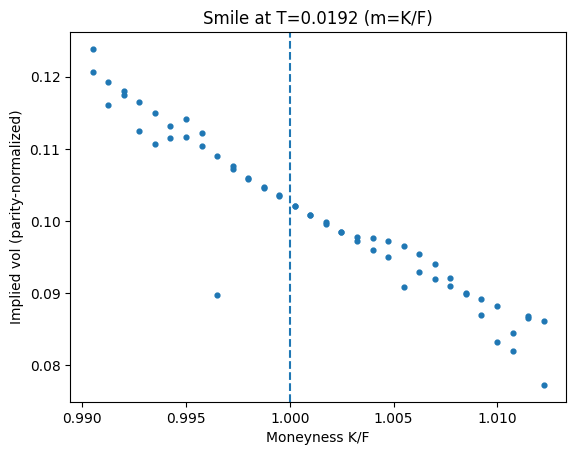

In [41]:
# plot smile at a chosen expiry

import matplotlib.pyplot as plt

ivp = pd.read_csv(f"artifacts/ivtable_parity_{ASOF}.csv")
ivp["m"] = ivp["K"] / ivp["F"]
ivp = ivp[(ivp["iv_parity"] > 0.02) & (ivp["iv_parity"] < 3.0)].copy()

# choose the closest expiry to, say, T≈0.02y
target = 0.02
Tstar = ivp.iloc[(ivp["T"] - target).abs().argmin()]["T"]
sl = ivp[ivp["T"] == Tstar].sort_values("m")

plt.scatter(sl["m"], sl["iv_parity"], s=12)
plt.axvline(1.0, ls="--")
plt.title(f"Smile at T={Tstar:.4f} (m=K/F)")
plt.xlabel("Moneyness K/F")
plt.ylabel("Implied vol (parity-normalized)")
plt.show()

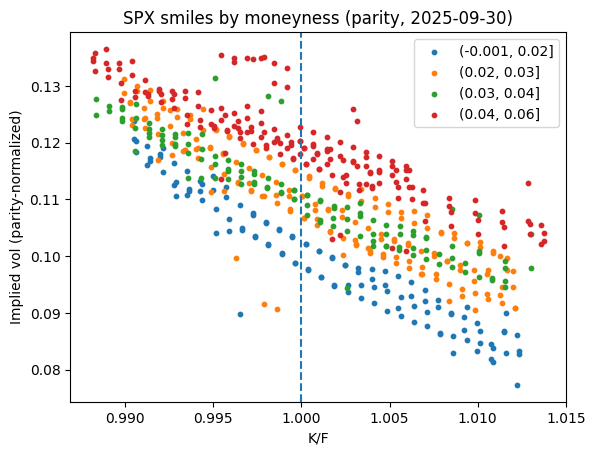

In [42]:
# plot multiple smiles by T-bins

bins = [0,0.02,0.03,0.04,0.06]
ivp["Tbin"] = pd.cut(ivp["T"], bins=bins, include_lowest=True)
for tbin, grp in ivp.groupby("Tbin"):
    if len(grp) == 0: 
        continue
    plt.scatter(grp["m"], grp["iv_parity"], s=10, label=str(tbin))
plt.axvline(1.0, ls="--")
plt.legend()
plt.xlabel("K/F")
plt.ylabel("Implied vol (parity-normalized)")
plt.title("SPX smiles by moneyness (parity, 2025-09-30)")
plt.show()


Step 6: Build the local volatility PDE pricer and check against our quotes

In [43]:
# Bilinear local vol interpolator from parquet

class BiLinearLV:
    """
    Interpolate sigma_loc(t,S) without requiring a rectangular (T,K) grid.
    For a query (t,S): find bracketing maturities tL,tU; for each,
    1D-interp sigma along that maturity's K-grid to get sL, sU; then blend in t.
    """
    def __init__(self, lv_parquet_path: str):
        df = pd.read_parquet(lv_parquet_path)
        need = {"T","K","sigma_loc"}
        if not need.issubset(df.columns):
            raise ValueError(f"Local vol parquet must have {need}, got {set(df.columns)}")
        # unique sorted maturities
        self.Ts = np.unique(df["T"].values)
        # per T, store sorted K and aligned sigma_loc
        self.Kmap = {}
        self.Smap = {}
        for T in self.Ts:
            sl = df[df["T"]==T].sort_values("K")
            K = sl["K"].to_numpy(dtype=float)
            s = sl["sigma_loc"].to_numpy(dtype=float)
            # defensive clamp
            s = np.clip(s, 1e-6, 5.0)
            self.Kmap[T] = K
            self.Smap[T] = s

        # global S bounds for clamping
        all_K = df["K"].to_numpy(dtype=float)
        self.Smin = float(np.min(all_K))
        self.Smax = float(np.max(all_K))

    def __call__(self, t, S):
        """Return sigma_loc(t,S). Handle scalar or numpy array S"""
        # clamp time
        t = float(np.clip(float(t), self.Ts[0], self.Ts[-1]))

        # locate bracketing maturities
        i = np.searchsorted(self.Ts, t)
        if i == 0:
            tL, tU, wt = self.Ts[0], self.Ts[0], 0.0
        elif i == len(self.Ts):
            tL, tU, wt = self.Ts[-1], self.Ts[-1], 0.0
        else:
            tL, tU = self.Ts[i-1], self.Ts[i]
            wt = 0.0 if tU==tL else (t - tL)/(tU - tL)

        # if S is scalar
        if np.isscalar(S):
            S = float(np.clip(S, self.Smin, self.Smax))
            sL = np.interp(S, self.Kmap[tL], self.Smap[tL])
            sU = np.interp(S, self.Kmap[tU], self.Smap[tU])
            s = sL * (1.0 - wt) + sU * wt
            return float(np.clip(s, 1e-6, 5.0))
        
        # if S is array
        S = np.asarray(S, dtype=float)
        S_clamped = np.clip(S, self.Smin, self.Smax)
        sL = np.interp(S_clamped, self.Kmap[tL], self.Smap[tL])
        sU = np.interp(S_clamped, self.Kmap[tU], self.Smap[tU])
        s = sL * (1.0 - wt) + sU * wt
        return np.clip(s, 1e-6, 5.0)


In [44]:
# Local vol pricing via Crank-Nicolson on spot grid

from dataclasses import dataclass
from typing import Literal, Tuple, Optional, Callable

PayoffCP = Literal["C","P"]

@dataclass
class GridSpec:
    S_min: float
    S_max: float
    nS: int
    nT: int

# helper to make a spot grid around K
def make_spot_grid(S0: float, K: float, T: float,
                   nS: int=401, nT: int=400,
                   span: Tuple[float,float]=(0.5,1.6)) -> GridSpec:
    Sref = K if K>0 else S0
    S_min = max(1e-8, Sref * span[0])
    S_max = Sref * span[1]
    return GridSpec(S_min=S_min, S_max=S_max, nS=nS, nT=nT)

# Crank-Nicolson solver on spot grid for local vol
def crank_nicolson_localvol(
    cp: PayoffCP,
    K: float,
    T: float,
    S0: float,
    lv_func: Callable[[float, np.ndarray], np.ndarray],
    r: float = 0.0,
    q: float = 0.0,
    grid: Optional[GridSpec] = None
):
    """
    European option under local vol via Crank-Nicholson on S-grid.
    PDE: u_t + 0.5*sigma_loc(t,S)^2*S^2*u_SS + (r-q)*S*u_S - r*u = 0, u(T,S)=payoff
    Returns (price, delta) at S0.
    """
    if T<= 0:
        # epiry: price is intrinsic
        if cp == "C":
            return max(S0 - K, 0.0), (1.0 if S0 > K else 0.0)
        else:
            return max(K - S0, 0.0), (-1.0 if S0 < K else 0.0)
        
    if grid is None:
        grid = make_spot_grid(S0, K, T)

    S_min, S_max, nS, nT = grid.S_min, grid.S_max, grid.nS, grid.nT
    S = np.linspace(S_min, S_max, nS)
    dS = S[1] - S[0]
    dt = T / nT if nT > 0 else 0.0

    # Terminal payoff
    if cp == "C":
        U = np.maximum(S - K, 0.0)
        def bc_left(t): return 0.0
        def bc_right(t): return S_max - K * np.exp(-r * (T - t)) if r != 0 else S_max - K
    else:
        U = np.maximum(K - S, 0.0)
        def bc_left(t): return K * np.exp(-r * (T - t)) - S_min if r != 0 else K - S_min
        def bc_right(t): return 0.0

    # Precompute S index around S0 for delta
    j0 = int(np.clip(np.searchsorted(S, S0), 1, nS-2))

    # March backwards
    for n in range(nT):
        t_next = T - n * dt # known time (terminal at start)
        t_curr = t_next - dt # target time
        t_mid = max(t_curr, 0.0) + 0.5 * dt

        sigma = np.asarray(lv_func(t_mid, S), dtype=float)
        sigma2 = np.clip(sigma, 1e-8, 5.0)**2

        # CN coefficients (standard)
        Acoef = 0.25 * dt * ( (sigma2*(S**2))/(dS**2) - ((r - q)*S)/dS )
        Bcoef = -0.5 * dt * ( (sigma2*(S**2))/(dS**2) + r )
        Ccoef = 0.25 * dt * ( (sigma2*(S**2))/(dS**2) + ((r - q)*S)/dS )

        # Implicit (A) tridiagonal for interior nodes 1..nS-2
        lower = -Acoef[2:-1].copy()         # length nS-3
        diag  = (1.0 - Bcoef[1:-1]).copy()  # length nS-2
        upper = -Ccoef[1:-2].copy()         # length nS-3

        # Explicit (B) application to previous U
        RHS = np.empty_like(U)
        RHS[1:-1] = (Acoef[1:-1]*U[:-2] + (1.0 + Bcoef[1:-1])*U[1:-1] + Ccoef[1:-1]*U[2:])

        # Dirichlet boundary contributions
        left_val = bc_left(t_curr)
        right_val = bc_right(t_curr)
        RHS[1] -= (-Acoef[1]) * left_val      # because lower diag coeff in A multiplies U[0]
        RHS[-2] -= (-Ccoef[-2]) * right_val   # because upper diag coeff in A multiplies U[-1]

        # Set boundary rows (Dirichlet)
        RHS[0] = left_val
        RHS[-1] = right_val

        # Solve interior by Thomas algorithm
        U_new = U.copy()
        # forward elimination (on interior system)
        for i in range(len(lower)):
            m = lower[i] / diag[i]
            diag[i+1] -= m * upper[i]
            RHS[i+2] -= m * RHS[i+1]
        # back substitution
        U_new[-2] = RHS[-2] / diag[-1]
        for i in range(len(lower)-1, -1, -1):
            U_new[i+1] = (RHS[i+1] - upper[i] * U_new[i+2]) / diag[i]

        # apply Dirichlet BCs
        U_new[0] = left_val
        U_new[-1] = right_val
        U = U_new

    price = float(np.interp(S0, S, U))
    delta = float((U[j0+1] - U[j0-1]) / (2.0 * dS))
    return price, delta    

In [45]:
# Pricing diagnostics via local vol PDE

ASOF = "2025-09-30"
DAY_CSV = f"data/quotes/{ASOF.replace('-','')}_quotes.csv"
LV_PARQ = f"artifacts/local_vol_surface_{ASOF}.parquet"

# load day and pick a few test options (near ATM across 3 expiries)
day = pd.read_csv(DAY_CSV)
asof = pd.to_datetime(ASOF)
day["T"] = (pd.to_datetime(day["expiry"]) - asof).dt.days / 365.0
day = day[(day["mid"]>0) & (day["T"]>0)].copy()

S0 = float(day["S"].median())

# prefer ~ATM per expiry
def pick_near_atm(df, per_exp=5):
    df = df.copy()
    df["dist"] = (df["K"] - S0).abs()
    return (df.sort_values(["expiry","dist"]).groupby("expiry").head(per_exp).drop(columns=["dist"]))

sample = pick_near_atm(day, per_exp=4).sort_values(["expiry","K","cp"]).head(12)
print("Testing N rows:", len(sample))

# local vol interpolator
lv_interp = BiLinearLV(LV_PARQ)

# price each sample option with PDE
rows = []
for r in sample.itertuples(index=False):
    cp, K, T, mid = r.cp, float(r.K), float(r.T), float(r.mid)
    price, delta = crank_nicolson_localvol(
        cp = r.cp,
        K  = K,
        T  = T,
        S0 = S0,
        lv_func = lv_interp,
        r = 0.0,
        q = 0.0,
        grid = make_spot_grid(S0, K, T, nS=401, nT=400, span=(0.4,1.8))
    )
    rows.append({
        "cp": cp,
        "K": K,
        "T": T,
        "mid": mid,
        "price_pde": price,
        "delta_pde": delta,
        "price_err": price - mid
    })

out = pd.DataFrame(rows)
print(out.head(10))
print("RMSE:", math.sqrt((out["price_err"]**2).mean()), " MAE:", out["price_err"].abs().mean())
out.to_csv(f"artifacts/pde_diag_{ASOF}.csv", index=False)
print("Wrote artifacts/pde_diag_*.csv")


Testing N rows: 12
  cp       K         T    mid  price_pde  delta_pde  price_err
0  C  6685.0  0.005479  13.35  25.511818   0.517427  12.161818
1  P  6685.0  0.005479  22.05  22.051818  -0.482573   0.001818
2  C  6690.0  0.005479  13.80  22.665410   0.513500   8.865410
3  P  6690.0  0.005479  28.20  24.205410  -0.486500  -3.994590
4  C  6685.0  0.008219  23.85  29.986037   0.489520   6.136037
5  P  6685.0  0.008219  31.65  26.526037  -0.510480  -5.123963
6  C  6690.0  0.008219  21.25  27.085706   0.483788   5.835706
7  P  6690.0  0.008219  34.10  28.625706  -0.516212  -5.474294
8  C  6685.0  0.016438  29.25  39.469901   0.442819  10.219901
9  P  6685.0  0.016438  36.85  36.009901  -0.557181  -0.840099
RMSE: 6.92035738823029  MAE: 5.801136361570825
Wrote artifacts/pde_diag_*.csv


In [46]:
# Unit test: compare PDE price vs Black-Scholes for constant vol
def bs_call(S, K, T, sigma, r=0.0, q=0.0):
    if T<=0: return max(S-K,0.0)
    vsqT = sigma*sigma*T
    v    = math.sqrt(vsqT)
    d1 = (math.log(S/K) + (r-q+0.5*vsqT)*T)/v
    d2 = d1 - v
    from math import erf, sqrt
    N = lambda x: 0.5*(1.0+erf(x/sqrt(2.0)))
    return math.exp(-q*T)*S*N(d1) - math.exp(-r*T)*K*N(d2)

S0, K, T, sig = 100.0, 100.0, 0.02, 0.20
lv_const = lambda t, S: np.full_like(S, sig, dtype=float)

pde_price, _ = crank_nicolson_localvol(
    cp="C", K=K, T=T, S0=S0, lv_func=lv_const, r=0.0, q=0.0,
    grid=make_spot_grid(S0, K, T, nS=501, nT=600, span=(0.5,1.6))
)

bs_price = bs_call(S0, K, T, sig, r=0.0, q=0.0)
print("PDE:", pde_price, " BS:", bs_price, "  abs diff:", abs(pde_price-bs_price))


PDE: 1.1288418693348254  BS: 1.128233202089028   abs diff: 0.0006086672457974451


In [47]:
# Pricing diagnostics via local vol PDE with F(T) drift

ASOF = "2025-09-30"
DAY_CSV = f"data/quotes/{ASOF.replace('-','')}_quotes.csv"
LV_PARQ = f"artifacts/local_vol_surface_{ASOF}.parquet"

# load day and pick a few test options (near ATM across 3 expiries)
day = pd.read_csv(DAY_CSV)
asof = pd.to_datetime(ASOF)
day["T"] = (pd.to_datetime(day["expiry"]) - asof).dt.days / 365.0
day = day[(day["mid"]>0) & (day["T"]>0)].copy()

ivtab = pd.read_csv(f"artifacts/ivtable_{ASOF}.csv") # has T, F, df columns
# build a tiny helper to fetch F(T) by nearest T
T_vals = ivtab["T"].to_numpy()
F_vals = ivtab["F"].to_numpy()

def F_for_T(T):
    # nearest neighbour in T
    j = int(np.argmin(np.abs(T_vals - float(T))))
    return float(F_vals[j])


S0 = float(day["S"].median())

# prefer ~ATM per expiry
def pick_near_atm(df, per_exp=5):
    df = df.copy()
    df["dist"] = (df["K"] - S0).abs()
    return (df.sort_values(["expiry","dist"]).groupby("expiry").head(per_exp).drop(columns=["dist"]))

sample = pick_near_atm(day, per_exp=4).sort_values(["expiry","K","cp"]).head(12)
print("Testing N rows:", len(sample))

# local vol interpolator
lv_interp = BiLinearLV(LV_PARQ)

# price each sample option with PDE
rows = []
for r in sample.itertuples(index=False):
    cp, K, T, mid = r.cp, float(r.K), float(r.T), float(r.mid)
    F_T = F_for_T(T)
    # effective risk-neutral drift: r - q = ln(F/S0)/T (guard T>0)
    rq = math.log(F_T / S0) / T if T > 0 else 0.0

    price, delta = crank_nicolson_localvol(
        cp = cp,
        K  = K,
        T  = T,
        S0 = S0,
        lv_func = lv_interp,
        r = rq,
        q = 0.0,
        grid = make_spot_grid(S0, K, T, nS=501, nT=600, span=(0.4,1.8))
    )
    rows.append({
        "cp": cp,
        "K": K,
        "T": T,
        "mid": mid,
        "price_pde": price,
        "delta_pde": delta,
        "price_err": price - mid,
        "rq": rq,
        "F_T" : F_T
    })

out = pd.DataFrame(rows)
print(out.head(10))
print("RMSE:", math.sqrt((out["price_err"]**2).mean()), " MAE:", out["price_err"].abs().mean())
out.to_csv(f"artifacts/pde_diag_{ASOF}.csv", index=False)
print("Wrote artifacts/pde_diag_*.csv")


Testing N rows: 12
  cp       K         T    mid  price_pde  delta_pde  price_err        rq  \
0  C  6685.0  0.005479  13.35  20.001371   0.440550   6.651371 -0.300664   
1  P  6685.0  0.005479  22.05  27.563819  -0.559450   5.513819 -0.300664   
2  C  6690.0  0.005479  13.80  17.375754   0.434769   3.575754 -0.300664   
3  P  6690.0  0.005479  28.20  29.946447  -0.565231   1.746447 -0.300664   
4  C  6685.0  0.008219  23.85  24.487353   0.425044   0.637353 -0.200443   
5  P  6685.0  0.008219  31.65  32.049802  -0.574956   0.399802 -0.200443   
6  C  6690.0  0.008219  21.25  21.769580   0.417792   0.519580 -0.200443   
7  P  6690.0  0.008219  34.10  34.340273  -0.582208   0.240273 -0.200443   
8  C  6685.0  0.016438  29.25  34.000844   0.395424   4.750844 -0.100221   
9  P  6685.0  0.016438  36.85  41.563293  -0.604576   4.713293 -0.100221   

       F_T  
0  6677.45  
1  6677.45  
2  6677.45  
3  6677.45  
4  6677.45  
5  6677.45  
6  6677.45  
7  6677.45  
8  6677.45  
9  6677.45  
R

In [48]:
#============ Full-day local volatility PDE Pricing Diagonostics ============

ASOF = "2025-09-30"
S0 = 6688.46
LV_PARQ = f"artifacts/local_vol_surface_{ASOF}.parquet"
DAY_CSV = f"data/quotes/{ASOF.replace('-','')}_quotes.csv"
IVTAB_CSV = f"artifacts/ivtable_{ASOF}.csv"
OUT_PDE = Path(f"artifacts/pde_diag_{ASOF}.csv")

# Load data
day = pd.read_csv(DAY_CSV)
ivtab = pd.read_csv(IVTAB_CSV)

# Helper: Forwads lookup + drift
T_vals = ivtab["T"].to_numpy()
F_vals = ivtab["F"].to_numpy()
def F_for_T(T):
    j = int(np.argmin(np.abs(T_vals - float(T))))
    return float(F_vals[j])

# Local vol interpolator
lv_interp = BiLinearLV(LV_PARQ)

rows = []
print(f"Testing N rows:", len(day))
for r in day.itertuples(index=False):
    cp, K, T, mid = r.cp, float(r.K), float(r.T), float(r.mid)
    if T<= 0 or not np.isfinite(mid):
        continue
    F_T = F_for_T(T)
    rq = math.log(F_T / S0) / T
    try:
        price, delta = crank_nicolson_localvol(
            cp = cp,
            K  = K,
            T  = T,
            S0 = S0,
            lv_func = lv_interp,
            r = rq,
            q = 0.0,
            grid = make_spot_grid(S0, K, T, nS=401, nT=600, span=(0.4,1.8))
        )
        rows.append({
            "cp": cp,
            "K": K,
            "T": T,
            "mid": mid,
            "price_pde": price,
            "delta_pde": delta,
            "price_err": price - mid,
            "rq": rq,
            "F_T" : F_T
        })
    except Exception as e:
        print(f"Error pricing cp={cp} K={K} T={T}: {e}")
        continue

pde_day = pd.DataFrame(rows)
rmse = np.sqrt(np.mean(pde_day["price_err"]**2))
mae  = np.mean(np.abs(pde_day["price_err"]))
print(f"PDE RMSE={rmse:.4f}   MAE={mae:.4f}   N={len(pde_day)}")

# Save diagnostics
OUT_PDE.parent.mkdir(exist_ok=True, parents=True)
pde_day.to_csv(OUT_PDE, index=False)
print(f"Wrote {OUT_PDE}")

Testing N rows: 720
PDE RMSE=20.4140   MAE=15.1799   N=720
Wrote artifacts/pde_diag_2025-09-30.csv


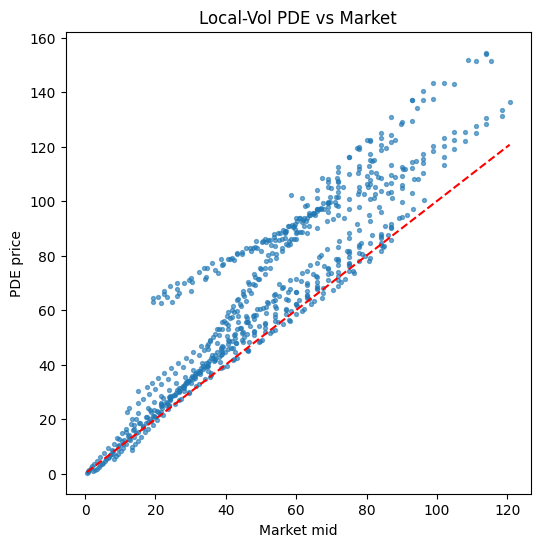

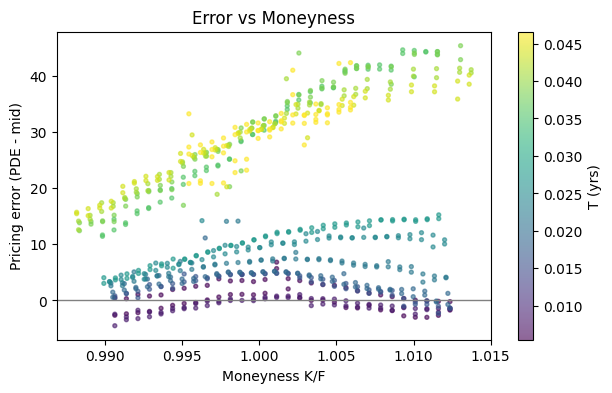

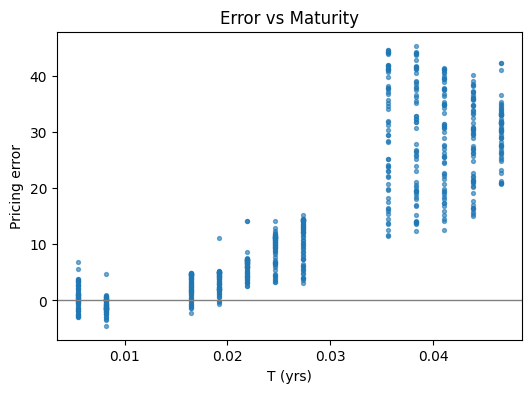

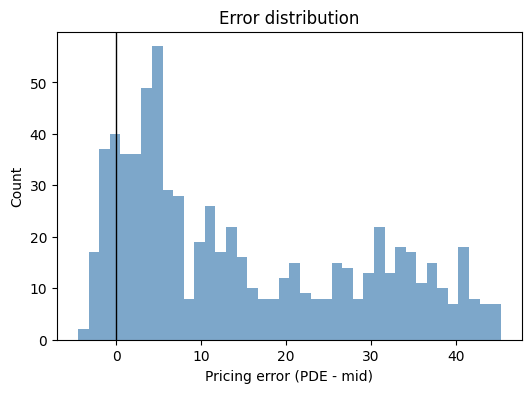

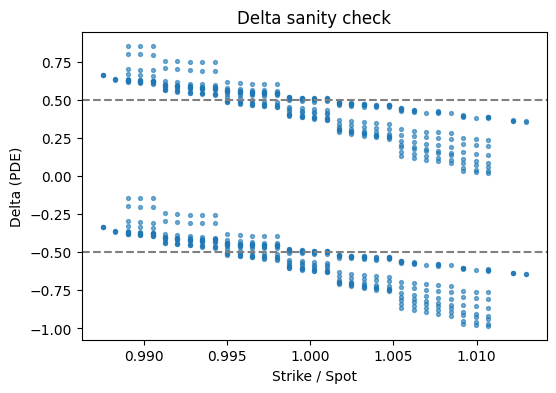

In [49]:
# === Price diagnostics plots ===

plt.figure(figsize=(6,6))
plt.scatter(pde_day["mid"], pde_day["price_pde"], s=8, alpha=0.6)
plt.plot([pde_day["mid"].min(), pde_day["mid"].max()],
         [pde_day["mid"].min(), pde_day["mid"].max()], 'r--')
plt.xlabel("Market mid")
plt.ylabel("PDE price")
plt.title("Local-Vol PDE vs Market")
plt.show()

# --- Error vs moneyness ---
# Build. moneyness directly from the PDE diag
pde_day["m"] = pde_day["K"] / pde_day["F_T"]

plt.figure(figsize=(7,4))
plt.scatter(pde_day["m"], pde_day["price_err"], s=8, alpha=0.6, c=pde_day["T"], cmap="viridis")
plt.axhline(0, color="gray", lw=1)
plt.xlabel("Moneyness K/F")
plt.ylabel("Pricing error (PDE - mid)")
plt.title("Error vs Moneyness")
plt.colorbar(label="T (yrs)")
plt.show()

# --- Error vs maturity ---
plt.figure(figsize=(6,4))
plt.scatter(pde_day["T"], pde_day["price_err"], s=8, alpha=0.6)
plt.axhline(0, color="gray", lw=1)
plt.xlabel("T (yrs)")
plt.ylabel("Pricing error")
plt.title("Error vs Maturity")
plt.show()

# --- Error histogram ---
plt.figure(figsize=(6,4))
plt.hist(pde_day["price_err"], bins=40, color="steelblue", alpha=0.7)
plt.axvline(0, color="black", lw=1)
plt.xlabel("Pricing error (PDE - mid)")
plt.ylabel("Count")
plt.title("Error distribution")
plt.show()

# --- Delta sanity check ---
plt.figure(figsize=(6,4))
plt.scatter(pde_day["K"]/S0, pde_day["delta_pde"], s=8, alpha=0.6)
plt.axhline(0.5, color="gray", ls="--")
plt.axhline(-0.5, color="gray", ls="--")
plt.xlabel("Strike / Spot")
plt.ylabel("Delta (PDE)")
plt.title("Delta sanity check")
plt.show()


In [50]:
# Next we build a comparison table for our three models:
# BSM baseline 
# Arbitrage free surface 
# Local volatility PDE

ASOF = "2025-09-30"
DIAG_SURF_BSM = Path(f"artifacts/pricing_diag_{ASOF}.csv") # earlier "surface vs market" + "bsm vs market"
DIAG_PDE = Path(f"artifacts/pde_diag_{ASOF}.csv")      # PDE diagonostics we just saved

def rmse_mae(x):
    x = np.asarray(x, dtype=float)
    return float(np.sqrt(np.mean(x**2))), float(np.mean(np.abs(x)))

# Load diagonostics
surf_bsm = pd.read_csv(DIAG_SURF_BSM) # expects cols: mid, price_fit, err (fit-mid), price_bsm, bsm_err
pde_day = pd.read_csv(DIAG_PDE)        # expects cols: mid, price_pde, price_err

# Global metrics
rmse_surf, mae_surf = rmse_mae(surf_bsm["err"])
rmse_bsm, mae_bsm   = rmse_mae(surf_bsm["bsm_err"])
rmse_pde, mae_pde   = rmse_mae(pde_day["price_err"])

comp = pd.DataFrame({
    "Model": ["BSM baseline", "Arb-free surface (price fit)", "Local vol PDE"],
    "RMSE": [rmse_bsm, rmse_surf, rmse_pde],
    "MAE": [mae_bsm, mae_surf, mae_pde]

}).sort_values("RMSE")
print("\n=== Overall model comparison (price space) ===")
print(comp.to_string(index=False))

# By tenor buckets
def bucket_T(T):
    # customise bins to the dataset; these works for 1d-45d region
    if T < 0.010: return "<1.0%"
    if T < 0.020: return "1.0-2.0%"
    if T < 0.030: return "2.0-3.0%"
    if T < 0.040: return "3.0-4.0%"
    return ">=4.0%"

sb_T = surf_bsm.assign(T_bucket=surf_bsm["T"].apply(bucket_T))
pde_T = pde_day.assign(T_bucket=pde_day["T"].apply(bucket_T))

rows = []
for tb in sorted(sb_T["T_bucket"].unique(), key=lambda s: ("<" not in s, s)):
    sb = sb_T[sb_T["T_bucket"]==tb]
    pded = pde_T[pde_T["T_bucket"]==tb]
    if len(sb) == 0 or len(pded) == 0:
        continue
    rs, ms = rmse_mae(sb["err"])
    rb, mb = rmse_mae(sb["bsm_err"])
    rp, mp = rmse_mae(pded["price_err"])
    rows.append([tb, rb, mb, len(sb), rs, ms, len(sb), rp, mp, len(pded)])
tenor_table = pd.DataFrame(rows, columns=[
    "Tenor bucket",
    "BSM RMSE", "BSM MAE", "N BSM",
    "Surf RMSE", "Surf MAE", "N Surf",
    "PDE RMSE", "PDE MAE", "N PDE"
])

print("\n=== Model comparison by tenor bucket ===")
print(tenor_table.to_string(index=False))

# ========By moneyness buckets (use PDE's own foward F_T)
def bucket_m(m):
    if m < 0.98: return "<0.98"
    if m < 1.00: return "0.98-1.00"
    if m < 1.02: return "1.00-1.02"
    return ">=1.02"

# build moneyness on both frames; SURF uses F via merge if available
surf_bsm["m"] = surf_bsm["K"] / surf_bsm["F"]
pde_day["m"] = pde_day["K"] / pde_day["F_T"]

sb_m = surf_bsm.dropna(subset=["m"]).assign(m_bucket=surf_bsm["m"].apply(bucket_m))
pde_m = pde_day.dropna(subset=["m"]).assign(m_bucket=pde_day["m"].apply(bucket_m))

# Iterate over buckets that actually exist in BOTH frames
buckets = sorted(set(sb_m["m_bucket"]).intersection(set(pde_m["m_bucket"])),
                 key=lambda s: {"<0.98":0, "0.98-1.00":1, "1.00-1.02":2, ">=1.02":3}[s])

rows = []
for mb in buckets:
    sb = sb_m[sb_m["m_bucket"]==mb]
    pded = pde_m[pde_m["m_bucket"]==mb]
    if len(sb) == 0 or len(pded) == 0:
        continue
    rs, ms = rmse_mae(sb["err"])
    rb, mbb = rmse_mae(sb["bsm_err"])
    rp, mp = rmse_mae(pded["price_err"])
    rows.append([mb, rb, mbb, len(sb), rs, ms, len(sb), rp, mp, len(pded)])

moneyness_table = pd.DataFrame(rows, columns=[
    "Moneyness bucket",
    "BSM RMSE", "BSM MAE", "N BSM",
    "Surf RMSE", "Surf MAE", "N Surf",
    "PDE RMSE", "PDE MAE", "N PDE"
])

print("\n=== Model comparison by moneyness bucket ===")
print(moneyness_table.to_string(index=False))



=== Overall model comparison (price space) ===
                       Model       RMSE        MAE
Arb-free surface (price fit)  20.175541  15.072873
               Local vol PDE  20.413982  15.179945
                BSM baseline 200.642151 171.090558

=== Model comparison by tenor bucket ===
Tenor bucket   BSM RMSE    BSM MAE  N BSM  Surf RMSE  Surf MAE  N Surf  PDE RMSE   PDE MAE  N PDE
    1.0-2.0% 193.650417 152.977261    106  21.678941 15.849721     106  3.516240  3.076134    120
    2.0-3.0% 206.659853 177.054943    169  20.735514 15.540060     169  9.214230  8.561417    180
    3.0-4.0% 209.397100 184.602393    118  18.909338 14.487755     118 31.668961 29.864830    120
      >=4.0% 192.940708 167.299624    180  19.517457 14.560336     180 30.042273 29.176449    180

=== Model comparison by moneyness bucket ===
Moneyness bucket   BSM RMSE    BSM MAE  N BSM  Surf RMSE  Surf MAE  N Surf  PDE RMSE   PDE MAE  N PDE
       0.98-1.00 202.027422 179.354217    276  11.835796  9.751686  

Step 7: Greeks (Delta, Gamma, Theta) from Local Volatility PDE vs Black-Scholes

Greek test rows: 100
Computed Greeks for N rows: 100

ATM-ish summary (|m-1|<=0.01)
       pde_delta  bsm_delta     pde_gamma  bsm_gamma    pde_theta  \
count  92.000000  92.000000  9.200000e+01  92.000000    92.000000   
mean    0.069929   0.100909  1.755685e-03   0.000613 -1667.291162   
std     0.502219   0.476176  5.309825e-03   0.000334   527.125509   
min    -0.574079  -0.480365 -1.421085e-14   0.000000 -2491.908756   
25%    -0.439844  -0.456394 -7.105427e-15   0.000469 -2050.350765   
50%     0.421852   0.515668  0.000000e+00   0.000557 -1786.156001   
75%     0.554430   0.541501  3.552714e-15   0.000718 -1356.264557   
max     0.676433   0.554475  2.934758e-02   0.002197  -478.250877   

          bsm_theta  
count     92.000000  
mean   -4695.502860  
std     2550.731836  
min   -11133.238170  
25%    -6451.148577  
50%    -4346.812265  
75%    -3218.736327  
max        0.000000  


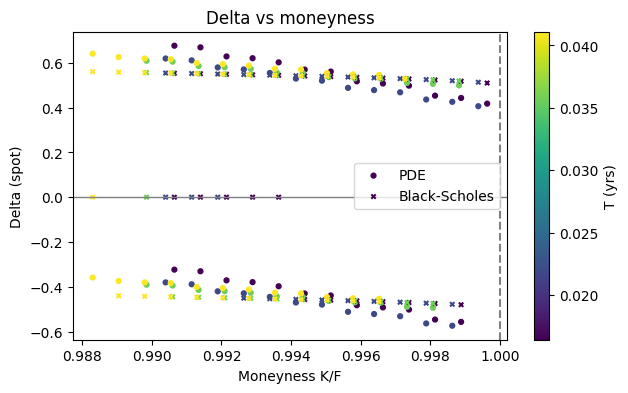

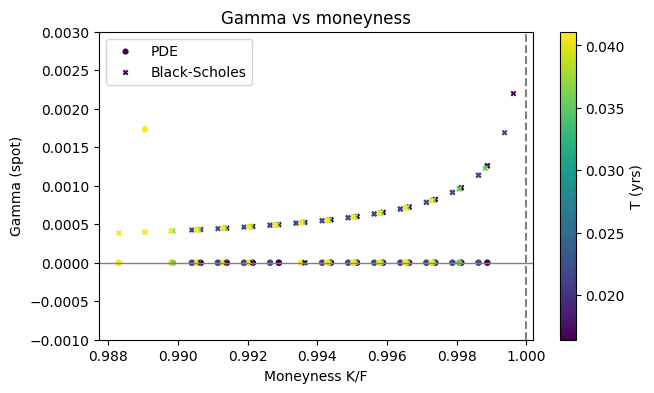

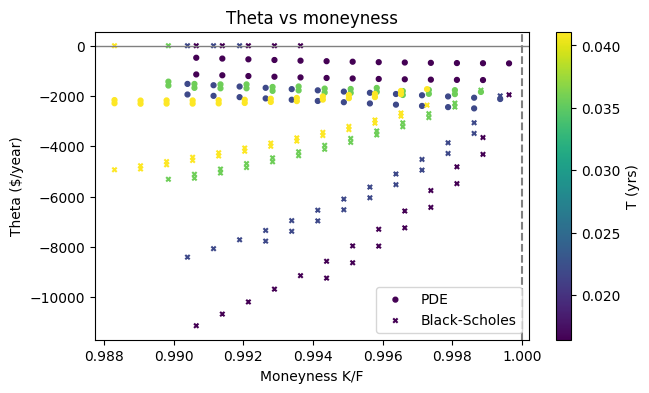

In [51]:
from scipy.stats import norm

ASOF = "2025-09-30"
S0 = 6688.46
LV_PARQ = f"artifacts/local_vol_surface_{ASOF}.parquet"
IVTABLE = f"artifacts/ivtable_{ASOF}.csv"
PDE_DIAG = f"artifacts/pde_diag_{ASOF}.csv"

# Load local volatility surface and tables
lv_interp = BiLinearLV(LV_PARQ)
ivtab = pd.read_csv(IVTABLE) # cols: cp,K,T,F,df,mid,iv,expiry
pde_diag = pd.read_csv(PDE_DIAG) # cols: cp,K,T,mid,price_pde,delta_pde,price_err,rq,F_T

# Build a test set: near-ATM and representative maturities
ivtab["m"] = ivtab["K"] / ivtab["F"]
test = (ivtab[(ivtab["m"].between(0.98,1.02)) & (ivtab["T"].between(0.01,0.045))]
        .copy().sort_values(["T","K"]))

# Thin it a bit (so plots aren't too dense)
test = test.groupby(pd.cut(test["T"], bins=[0.01,0.02,0.03,0.04,0.05], include_lowest=True)).head(25)
print("Greek test rows:", len(test))

# Helpers: nearest-forward lookup and PDE wrapper with correct drift
T_vals = pde_diag["T"].to_numpy()
F_vals = pde_diag["F_T"].to_numpy()
def F_for_T(T):
    j = int(np.argmin(np.abs(T_vals - float(T))))
    return float(F_vals[j])

def price_pde_spot(cp, K, T, S, rq=None, grid_nS=401, grid_nT=600, span=(0.6,1.4)):
    if T <= 0:
        p = max(S - K, 0.0) if cp == "C" else max(K - S, 0.0)
        d = (1.0 if (cp=="C" and S>K) else (-1.0 if (cp=="P" and S<K) else 0.0))
        return float(p), float(d)
    F_T = F_for_T(T)
    if rq is None:
        rq = math.log(F_T / S) / T # anchor at this S only
    price, delta = crank_nicolson_localvol(
        cp = cp,
        K  = float(K),
        T  = float(T),
        S0 = float(S),
        lv_func = lv_interp,
        r = rq,
        q = 0.0,
        grid = make_spot_grid(S, K, T, nS=grid_nS, nT=grid_nT, span=span)
    )
    return float(price), float(delta)

# PDE finite difference Greeks (central Delta/Gamma, one sided Theta)
def pde_greeks(cp, K, T, S, hS=1.0, hT=1/365.0):
    # lock rq at the center S so bumps only change S
    F_T = F_for_T(T)
    rq0 = math.log(F_T / S) / T

    # Delta, Gamma by spot bumps (Keep T fixed; foward is re-anchored inside price_pde_spot)
    p_minus, _ = price_pde_spot(cp, K, T, S - hS, rq=rq0)
    p0, delta0 = price_pde_spot(cp, K, T, S, rq=rq0)
    p_plus, _  = price_pde_spot(cp, K, T, S + hS, rq=rq0)
    # spot sensitivities
    delta = (p_plus - p_minus) / (2.0 * hS)
    gamma = (p_plus - 2.0 * p0 + p_minus) / (hS * hS)
    
    # Theta: decrease T wile keeping rq fixed at S
    T2 = max(T - hT, 1e-6)
    p_T2, _ = price_pde_spot(cp, K, T2, S, rq=rq0)
    theta = (p_T2 - p0) / hT  # ∂P/∂t ≈ (p_T2 - p0)/hT
    return delta, gamma, theta, p0

# BSM Greeks (analytic) converted to SPOT Greeks
# price: df*(cp*(F N(cp d1) - K N(cp d2)))
# ∂Price/∂F = df * N(cp*d1) * cp
# Spot delta = (∂Price/∂F) * ∂F/∂S = df * N(cp*d1) * (F/S)
def bsm_greeks(cp, F, K, T, sigma, df, S):
    if T <= 0 or sigma <= 0 or F <= 0 or K <= 0 or df <= 0:
        return np.nan , np.nan , np.nan , np.nan
    cpv = 1.0 if cp == "C" else -1.0
    vol_sqrtT = sigma * sqrt(T)
    d1 = (math.log(F / K) / vol_sqrtT) + 0.5 * vol_sqrtT
    d2 = d1 - vol_sqrtT
    # price
    price = df * (cpv * (F * norm.cdf(cpv * d1) - K * norm.cdf(cpv * d2)))

    # forward delta/gamma and then map to spot
    dP_dF = df * norm.cdf(cpv * d1) * cpv
    d2P_dF2 = df * norm.pdf(d1) / (F * sigma * sqrt(T))
    # convert to spot delta/gamma via F = S * exp((r - q)*T) => ∂F/∂S = F/S
    dF_dS = F / S
    delta = dP_dF * dF_dS
    gamma = d2P_dF2 * (dF_dS**2)

    # calendar theta: reduce T by hT, evolve F with the same rq = ln(F/S)/T
    hT = 1/365.0
    T2 = max(T - hT, 1e-6)
    rq = math.log(F / S) / T
    F2 = S * math.exp(rq * T2)
    vol_sqrtT2 = sigma * sqrt(T2)
    d1_2 = (math.log(F2 / K) / vol_sqrtT2) + 0.5 * vol_sqrtT2
    d2_2 = d1_2 - vol_sqrtT2
    price_T2 = df * (cpv * (F2 * norm.cdf(cpv * d1_2) - K * norm.cdf(cpv * d2_2)))
    theta = (price_T2 - price) / hT  # negative for long options in typical regimes
    return delta, gamma, theta, price

# Compute Greeks for the test set
rows = []
for r in test.itertuples(index=False):
    cp, K, T, F, df, iv = r.cp, float(r.K), float(r.T), float(r.F), float(r.df), float(r.iv)
    # PDE Greeks for spot S0
    delta_pde, gamma_pde, theta_pde, price_pde = pde_greeks(cp, K, T, S0, hS=1.0, hT=1/365)
    #if cp =="P":
    #    delta_pde = -delta_pde  # ensure put delta sign convention
    # BSM Greeks using same (F, K, T, iv, df) mapped to spot
    delta_bsm, gamma_bsm, theta_bsm, price_bsm = bsm_greeks(cp, F, K, T, iv, df, S0)
    rows.append({
        "cp": cp,
        "K": K,
        "T": T,
        "m": K / F,
        "pde_delta": delta_pde,
        "pde_gamma": gamma_pde,
        "pde_theta": theta_pde,
        "pde_price": price_pde,
        "bsm_delta": delta_bsm,
        "bsm_gamma": gamma_bsm,
        "bsm_theta": theta_bsm,
        "bsm_price": price_bsm
    })

greeks = pd.DataFrame(rows).dropna()
print("Computed Greeks for N rows:", len(greeks))
print("\nATM-ish summary (|m-1|<=0.01)")
atm = greeks[greeks["m"].between(0.99,1.01)]
print(atm[["pde_delta","bsm_delta","pde_gamma","bsm_gamma","pde_theta","bsm_theta"]].describe())

# --- Plots: Δ, Γ, Θ vs moneyness (color by T) ---
cmap = plt.cm.viridis

plt.figure(figsize=(7,4))
plt.scatter(greeks["m"], greeks["pde_delta"], s=12, c=greeks["T"], cmap=cmap, label="PDE")
plt.scatter(greeks["m"], greeks["bsm_delta"], s=10, c=greeks["T"], cmap=cmap, marker="x", label="Black-Scholes")
plt.axhline(0, color="gray", lw=1); plt.axvline(1.0, color="gray", ls="--")
plt.xlabel("Moneyness K/F"); plt.ylabel("Delta (spot)"); plt.title("Delta vs moneyness")
plt.colorbar(label="T (yrs)"); plt.legend(); plt.show()

plt.figure(figsize=(7,4))
plt.scatter(greeks["m"], greeks["pde_gamma"], s=12, c=greeks["T"], cmap=cmap, label="PDE")
plt.scatter(greeks["m"], greeks["bsm_gamma"], s=10, c=greeks["T"], cmap=cmap, marker="x", label="Black-Scholes")
plt.axhline(0, color="gray", lw=1); plt.axvline(1.0, color="gray", ls="--")
plt.ylim(-0.001, 0.003)
plt.xlabel("Moneyness K/F"); plt.ylabel("Gamma (spot)"); plt.title("Gamma vs moneyness")
plt.colorbar(label="T (yrs)"); plt.legend(); plt.show()

plt.figure(figsize=(7,4))
plt.scatter(greeks["m"], greeks["pde_theta"], s=12, c=greeks["T"], cmap=cmap, label="PDE")
plt.scatter(greeks["m"], greeks["bsm_theta"], s=10, c=greeks["T"], cmap=cmap, marker="x", label="Black-Scholes")
plt.axhline(0, color="gray", lw=1); plt.axvline(1.0, color="gray", ls="--")
plt.xlabel("Moneyness K/F"); plt.ylabel("Theta ($/year)"); plt.title("Theta vs moneyness")
plt.colorbar(label="T (yrs)"); plt.legend(); plt.show()



### Part B: Multi day Local Volatility Pricer

Part B of this notebook implements the following tasks for multiple days:
- Generate the following files for each business day of the specified period:
    - data/quotes/{YYYYMMDD}_quotes.csv
    - artifacts/forwards_{ASOF}.csv
    - artifacts/qcurve_{ASOF}.csv
    - artifacts/ivtable_{ASOF}.csv
    - artifacts/price_surface_{ASOF}.parquet
    - artifacts/local_vol_surface_{ASOF}.parquet
- 1-day delta-hedge backtest and generate P&L
- Rolling out-of-sample backtest across many days
NOTE: The code for the rolling backtest across many days in included in this notebook for completeness.
    Since the runtime is approximately 15 mins per day, this code was parallelized so that multiple
    CPU nodes on the Sol supercomputer at ASU would parallely run the backtesting, one for each day.
    This ensures that the speed-up is N times where N is the number of days over which the backtest is done.


In [52]:
from pathlib import Path

R_FLAT = 0.0     # can wire OIS curve later
T_MIN = 1/365.0  # ignore ultra-short for stability

def _is_business_day(asof: str) -> bool:
    d = pd.Timestamp(asof)
    return d.weekday() < 5  # 0 = Monday, 6 = Sunday

def _safe_read_csv(path: str) -> pd.DataFrame:
    return pd.read_csv(path) if path.exists() else pd.DataFrame()

def _ensure_dirs():
    Path("data/quotes").mkdir(parents=True, exist_ok=True)
    Path("artifacts").mkdir(parents=True, exist_ok=True)

def build_day_all(
        ASOF: str,
        # surface tuning defaults
        nK=61, K_lo=0.6, K_hi=1.6, max_expiries=10, lambda_KK=1e-6, lambda_T=5e-6,
        #controls
        force=False,
        min_quotes = 100, # skip day if fewer than this many quotes
        verbose=True,
):
    """
    One-call daily builder: NBBO -> forwards -> qcurve -> ivtable -> arb-free surface + local vol.

    Outputs (all under artifacts/ unless noted):
        data/quotes/{YYYYMMDD}_quotes.csv
        artifacts/forwards_{ASOF}.csv
        artifacts/qcurve_{ASOF}.csv
        artifacts/ivtable_{ASOF}.csv
        artifacts/price_surface_{ASOF}.parquet
        artifacts/local_vol_surface_{ASOF}.parquet

    Returns dict with paths and small summary.
    """
    _ensure_dirs()
    if not _is_business_day(ASOF):
        if verbose: print(f"{ASOF} is not a business day, skipping.")
        return {"asof": ASOF, "skipped": "not business day"}
    
    # -----paths -------
    QUOTES_CSV = Path(f"data/quotes/{ASOF.replace('-','')}_quotes.csv")
    FWDS_CSV = Path(f"artifacts/forwards_{ASOF}.csv")
    QCURVE_CSV = Path(f"artifacts/qcurve_{ASOF}.csv")
    IVTAB_CSV = Path(f"artifacts/ivtable_{ASOF}.csv")
    SURF_PQ = Path(f"artifacts/price_surface_{ASOF}.parquet")
    LV_PQ = Path(f"artifacts/local_vol_surface_{ASOF}.parquet")

    # ----- step 1: quotes (NBBO) -----
    if QUOTES_CSV.exists() and not force:
        if verbose: print(f"Quotes for {ASOF} already exist at {QUOTES_CSV}")
        day = pd.read_csv(QUOTES_CSV)
    else:
        if verbose: print(f"Loading quotes for {ASOF}...")
        day = build_day_from_quotes(ASOF, str(QUOTES_CSV))
    if day.empty or len(day) < min_quotes:
        if verbose: print(f"Insufficient quotes ({len(day)}) for {ASOF}, skipping.")
        return {"asof": ASOF, "skipped": "insufficient quotes"}
    
    # ----- step 2: forwards via put-call parity -----
    if FWDS_CSV.exists() and not force:
        if verbose: print(f"Forwards for {ASOF} already exist at {FWDS_CSV}")
        fwd_by_T = pd.read_csv(FWDS_CSV)
    else:
        df = day.copy()
        need = {"cp", "K", "T", "mid", "S"}
        missing = need - set(df.columns)
        if missing: raise SystemExit(f"[{ASOF}] Quotes CSV missing columns: {missing}")

        df = df[(df["T"] > 0) & (df["mid"] > 0)].copy()
        pairs = make_pairs_on_expiryK(df, ASOF)
        if pairs.empty:
            raise SystemExit(f"[{ASOF}] No C/P pairs formed; widen selection or inspect quotes.")
        pairs = parity_forward(pairs, r=0.0)

        # choose a representative per T near-ATM
        pairs["moneyness"] = pairs["K"] / pairs["F"]
        fwd_by_T = pairs.loc[pairs.groupby("T")["moneyness"].apply(lambda s: (s-1.0).abs().idxmin())][["T","K","C","P","F"]].sort_values("T")
        fwd_by_T.to_csv(FWDS_CSV, index=False)
        if verbose: print(f"[{ASOF}] Wrote forwards → {FWDS_CSV} (rows={len(fwd_by_T)})")

    if fwd_by_T.empty:
        return {"asof": ASOF, "skipped": "no forwards"}
    
    # ----- step 3: q-curve (F(T), q(T))-----
    if QCURVE_CSV.exists() and not force:
        if verbose: print(f"Q-curve for {ASOF} already exist at {QCURVE_CSV}")
        qcurve = pd.read_csv(QCURVE_CSV)
    else:
        S = float(day["S"].median())
        fwd = fwd_by_T.copy()
        fwd = fwd[fwd["T"] >= T_MIN].copy()
        if fwd.empty:
            return {"asof": ASOF, "skipped": "no forwards after T_MIN filter"}
        
        # q(T) = r - ln(F/S)/T  (r=0 here)
        fwd["q"] = R_FLAT - (1.0 / fwd["T"]) * np.log(fwd["F"] / S)
        fwd = fwd[(fwd["q"] > -0.20) & (fwd["q"] < 0.20)].copy()
        qcurve = fwd[["T","F","q"]].sort_values("T").reset_index(drop=True)
        qcurve.to_csv(QCURVE_CSV, index=False)
        if verbose: print(f"[{ASOF}] Wrote q-curve → {QCURVE_CSV} (rows={len(qcurve)})")

    if qcurve.empty:
        return {"asof": ASOF, "skipped": "no q-curve"}
    
    # ----- step 4: IV table -----
    if IVTAB_CSV.exists() and not force:
        if verbose: print(f"IV table for {ASOF} already exist at {IVTAB_CSV}")
        ivtab = pd.read_csv(IVTAB_CSV)
    else:
        qc = qcurve.copy()
        asof_ts = pd.to_datetime(ASOF)
        day2 = day.copy()
        day2["T2"] = (pd.to_datetime(day2["expiry"]) - asof_ts).dt.days / 365.0

        qc["T_round"]  = (qc["T"] * 10000).round().astype(int)
        day2["T_round"] = (day2["T2"] * 10000).round().astype(int)
        m = day2.merge(qc[["T_round","F","q"]], on="T_round", how="left")
        m["df"] = np.exp(-(R_FLAT) * m["T2"])

        m = m[(m["mid"] > 0) & (m["K"] > 0) & (m["df"] > 0) & m["F"].notna()].copy()

        ivs = []
        for cp, F, K, T, df, mid in zip(m["cp"], m["F"], m["K"], m["T2"], m["df"], m["mid"]):
            try:
                iv = iv_solve(cp, float(F), float(K), float(T), float(df), float(mid))
                ivs.append(iv)
            except Exception:
                ivs.append(float("nan"))
        m["iv"] = ivs

        out = m[["cp","K","T2","F","df","mid","iv","expiry"]].rename(columns={"T2":"T"})
        out = out.sort_values(["T","K","cp"])
        out.to_csv(IVTAB_CSV, index=False)
        if verbose:
            print(f"[{ASOF}] Wrote IV table → {IVTAB_CSV} (valid IVs={out['iv'].notna().sum()} / {len(out)})")
        ivtab = out

    if ivtab.empty:
        return {"asof": ASOF, "skipped": "no iv table"}
    
    # ----- step 5: arbitrage-free surface + local vol -----
    if SURF_PQ.exists() and LV_PQ.exists() and not force:
        if verbose: print(f"Surface and LV for {ASOF} already exist at {SURF_PQ} and {LV_PQ}")
        fit_info = {"skipped": "surface and LV exist"}
    else:
        fit_info = fit_and_save(
            str(QUOTES_CSV), str(FWDS_CSV), ASOF,
            nK=nK, K_lo=K_lo, K_hi=K_hi,
            max_expiries=max_expiries,
            lambda_KK=lambda_KK, lambda_T=lambda_T,
        )
        if verbose:
            print(f"[{ASOF}] Surface fit summary: {fit_info}")
            print(f"[{ASOF}] Wrote surface → {SURF_PQ} and LV → {LV_PQ}")

    return {
        "asof": ASOF,
        "quotes_csv": str(QUOTES_CSV),
        "forwards_csv": str(FWDS_CSV),
        "qcurve_csv": str(QCURVE_CSV),
        "ivtable_csv": str(IVTAB_CSV),
        "surface_parquet": str(SURF_PQ),
        "localvol_parquet": str(LV_PQ),
        "fit_info": fit_info
    }


In [53]:
# iterate over date range

# Business day generator
def business_days(start_iso: str, end_iso: str):
    # Simple Mon-Fri generator
    return [d.strftime("%Y-%m-%d") for d in pd.bdate_range(start_iso, end_iso)]

# Build over date range
def build_range(start_iso: str, end_iso: str, force=False):
    days = business_days(start_iso, end_iso)
    results = []
    for d in days:
        try:
            info = build_day_all(d, force=force, verbose=True)
        except SystemExit as e:
            print(f"[{d}] Aborted: {e}")
            info = {"asof": d, "error": str(e)}
        except Exception as e:
            print(f"[{d}] Error: {e}")
            info = {"asof": d, "error": repr(e)}
        results.append(info)
    out = pd.DataFrame(results)
    Path("artifacts").mkdir(parents=True, exist_ok=True)
    out.to_csv("artifacts/daily_build_log.csv", index=False)
    print("\nWrote artifacts/daily_build_log.csv")
    return out

In [57]:
# lets build
log = build_range("2025-09-02", "2025-10-02", force=False)
log.tail()

Quotes for 2025-09-02 already exist at data/quotes/20250902_quotes.csv
Forwards for 2025-09-02 already exist at artifacts/forwards_2025-09-02.csv
Q-curve for 2025-09-02 already exist at artifacts/qcurve_2025-09-02.csv
IV table for 2025-09-02 already exist at artifacts/ivtable_2025-09-02.csv
Surface and LV for 2025-09-02 already exist at artifacts/price_surface_2025-09-02.parquet and artifacts/local_vol_surface_2025-09-02.parquet
Quotes for 2025-09-03 already exist at data/quotes/20250903_quotes.csv
Forwards for 2025-09-03 already exist at artifacts/forwards_2025-09-03.csv
Q-curve for 2025-09-03 already exist at artifacts/qcurve_2025-09-03.csv
IV table for 2025-09-03 already exist at artifacts/ivtable_2025-09-03.csv
Surface and LV for 2025-09-03 already exist at artifacts/price_surface_2025-09-03.parquet and artifacts/local_vol_surface_2025-09-03.parquet
Quotes for 2025-09-04 already exist at data/quotes/20250904_quotes.csv
Forwards for 2025-09-04 already exist at artifacts/forwards_202

,asof,quotes_csv,forwards_csv,qcurve_csv,ivtable_csv,surface_parquet,localvol_parquet,fit_info
18,2025-09-26,data/quotes/20250926_quotes.csv,artifacts/forwards_2025-09-26.csv,artifacts/qcurve_2025-09-26.csv,artifacts/ivtable_2025-09-26.csv,artifacts/price_surface_2025-09-26.parquet,artifacts/local_vol_surface_2025-09-26.parquet,"{'nT': 10, 'nK': 61, 'grid_T_min_max': (0.0082..."
19,2025-09-29,data/quotes/20250929_quotes.csv,artifacts/forwards_2025-09-29.csv,artifacts/qcurve_2025-09-29.csv,artifacts/ivtable_2025-09-29.csv,artifacts/price_surface_2025-09-29.parquet,artifacts/local_vol_surface_2025-09-29.parquet,{'skipped': 'surface and LV exist'}
20,2025-09-30,data/quotes/20250930_quotes.csv,artifacts/forwards_2025-09-30.csv,artifacts/qcurve_2025-09-30.csv,artifacts/ivtable_2025-09-30.csv,artifacts/price_surface_2025-09-30.parquet,artifacts/local_vol_surface_2025-09-30.parquet,{'skipped': 'surface and LV exist'}
21,2025-10-01,data/quotes/20251001_quotes.csv,artifacts/forwards_2025-10-01.csv,artifacts/qcurve_2025-10-01.csv,artifacts/ivtable_2025-10-01.csv,artifacts/price_surface_2025-10-01.parquet,artifacts/local_vol_surface_2025-10-01.parquet,"{'nT': 10, 'nK': 61, 'grid_T_min_max': (0.0054..."
22,2025-10-02,data/quotes/20251002_quotes.csv,artifacts/forwards_2025-10-02.csv,artifacts/qcurve_2025-10-02.csv,artifacts/ivtable_2025-10-02.csv,artifacts/price_surface_2025-10-02.parquet,artifacts/local_vol_surface_2025-10-02.parquet,{'skipped': 'surface and LV exist'}


Step 8: One-day delta-hedged backtest

In [58]:
# --- Config ---
ASOF0 = "2025-09-30"         # day 0
ASOF1 = "2025-10-01"         # next trading day
R_FLAT = 0.0                  # carry (we used rq from forwards anyway)
PDE_GRID = dict(nS=501, nT=600, span=(0.45,1.75))  # PDE grid config
SUBSET = dict(max_expiries=8, m_band=(0.95, 1.05))  # subset of options to price

def day_files(asof):
    ymd = asof.replace("-", "")
    return dict(
        quotes=f"data/quotes/{ymd}_quotes.csv",
        ivtab=f"artifacts/ivtable_{asof}.csv",
        lvparq=f"artifacts/local_vol_surface_{asof}.parquet",
        fwds=f"artifacts/forwards_{asof}.csv",
    )

def load_day(asof):
    files = day_files(asof)
    day = pd.read_csv(files["quotes"])
    iv = pd.read_csv(files["ivtab"])
    lv = pd.read_parquet(files["lvparq"])
    return day, iv, lv

# ------Build foward curve F(T) as a function ------
def F_curve_from_ivtab(ivtab: pd.DataFrame):
    # F in ivtable is per-row; we'll median by rounded T to be robust
    tmp = ivtab.copy()
    tmp["T_key"] = (tmp["T"]*10000).round().astype(int)
    F_by_T = tmp.groupby("T_key")["F"].median().reset_index()
    grid_T = F_by_T["T_key"].to_numpy() / 10000.0
    grid_F = F_by_T["F"].to_numpy()

    # piecewise linear in T
    def F_of_T(t):
        t = np.clip(t, grid_T.min(), grid_T.max())
        return float(np.interp(t, grid_T, grid_F))
    return F_of_T

In [59]:
# ------ Bilinear LV interpolator ------

class BiLinearLV:
    def __init__(self, lv_parquet_path: str):
        df = pd.read_parquet(lv_parquet_path)
        self.Ts = np.array(sorted(df["T"].unique()))
        Kmap = {}
        Sigmap = {}
        for T in self.Ts:
            row = df[df["T"]==T].sort_values("K")
            Kmap[T] = row["K"].to_numpy()
            Sigmap[T] = row["sigma_loc"].to_numpy()
        # pad to rectangular grid
        self.Ks = np.unique(np.concatenate([v for v in Kmap.values()]))
        self.SIG = np.empty((len(self.Ts), len(self.Ks)))
        self.SIG[:]=np.nan
        for i, T in enumerate(self.Ts):
            Ks, Sg = Kmap[T], Sigmap[T]
            self.SIG[i,:] = np.interp(self.Ks, Ks, Sg, left=Sg[0], right=Sg[-1])
        self.SIG = np.clip(self.SIG, 1e-6, 5.0)
        self.Tmin, self.Tmax = float(self.Ts[0]), float(self.Ts[-1])
        self.Kmin, self.Kmax = float(self.Ks[0]), float(self.Ks[-1])

    def __call__(self, t, S):
        """
        Vectorized bilinear interpolation:
        - t: scalar maturity
        - S: scalar or 1D array of spot nodes (we treat S along the 'K' axis of the LV grid)
        Returns array with same shape as S (or scalar if S is a scalar)
        """
        # clamp t and compute time weights
        t = float(np.clip(float(t), self.Tmin, self.Tmax))
        i = np.searchsorted(self.Ts, t)
        i0 = max(i-1, 0); i1 = min(i, len(self.Ts)-1)
        t0, t1 = self.Ts[i0], self.Ts[i1]
        w_t = 0.0 if t1==t0 else (t - t0) / (t1 - t0)

        # prepare S as array and clamp to grid bounds
        S_arr = np.asarray(S, dtype=float)
        S_arr = np.clip(S_arr, self.Kmin, self.Kmax)

        # interpolate in K on the two time slices then blend across t
        s0 = np.interp(S_arr, self.Ks, self.SIG[i0,:], left=self.SIG[i0,0], right=self.SIG[i0,-1])
        s1 = np.interp(S_arr, self.Ks, self.SIG[i1,:], left=self.SIG[i1,0], right=self.SIG[i1,-1])
        sig = s0 * (1 - w_t) + s1 * w_t

        # clamp small/huge values for numerical stability
        sig = np.clip(sig, 1e-6, 5.0)

        # return scalar if input was scalar
        return float(sig) if np.ndim(S) == 0 else sig


In [60]:
# Repeat BSM function to compute price and delta
def black_price(cp: str, F: float, K: float, T: float, sigma: float, df: float):
    if T <= 0 or sigma <= 0 or F <= 0 or K <= 0 or df <= 0:
        return max(df*(F - K), 0.0) if cp == "C" else max(df*(K - F), 0.0)
    vol_sqrtT = sigma * sqrt(T)
    d1 = (math.log(F / K) / vol_sqrtT) + 0.5 * vol_sqrtT
    d2 = d1 - vol_sqrtT
    sgn = 1.0 if cp == "C" else -1.0
    price = df * (sgn * (F * norm.cdf(sgn * d1) - K * norm.cdf(sgn * d2)))
    return price

def black_delta_spot(cp: str, F: float, K: float, T: float, sigma: float, df: float, S: float):
    if T <= 0 or sigma <= 0 or F <= 0 or K <= 0 or df <= 0 or S <= 0:
        return 0.0
    vol_sqrtT = sigma * sqrt(T)
    d1 = (math.log(F / K) / vol_sqrtT) + 0.5 * vol_sqrtT
    sgn = 1.0 if cp == "C" else -1.0
    dP_dF = df * norm.cdf(sgn * d1) * sgn
    dF_dS = F / S
    delta = dP_dF * dF_dS
    return delta

In [61]:
# Robust bump-and-reprice delta for the PDE

def price_pde_only(cp, K, T, S0, lv_func, rq, grid_kwargs):
    """Return PDE price only (no delta), handy for bump-and-reprice."""
    price, _delta = crank_nicolson_localvol(
        cp = cp,
        K  = float(K),
        T  = float(T),
        S0 = float(S0),
        lv_func = lv_func,
        r = rq,
        q = 0.0,
        grid = make_spot_grid(S0, K, T, **grid_kwargs)
    )
    return float(price)

def pde_delta_bump(cp, K, T, S0, lv_func, rq, grid_kwargs, eps=1e-3):
    """Central finite-difference delta using PDE prices."""
    S_up = S0 * (1.0 + eps)
    S_down = S0 * (1.0 - eps)
    p_up = price_pde_only(cp, K, T, S_up, lv_func, rq, grid_kwargs)
    p_down = price_pde_only(cp, K, T, S_down, lv_func, rq, grid_kwargs)
    delta = (p_up - p_down) / (2.0 * S0 * eps)
    return float(delta)

In [62]:
# Build test set for day 0
day0, iv0, lv0 = load_day(ASOF0)
F0 = F_curve_from_ivtab(iv0)
lvf0 = BiLinearLV(day_files(ASOF0)["lvparq"])

# filter to a compact universe (liquidity + compute time)
S0 = float(day0["S"].median())
m = day0["K"] / S0
univ0 = (day0[(m>=SUBSET["m_band"][0]) & (m<=SUBSET["m_band"][1])].copy())

# keep first N expiries by unique T
asof0 = pd.to_datetime(ASOF0)
univ0["T"] = (pd.to_datetime(univ0["expiry"]) - asof0).dt.days / 365.0
exps = sorted(univ0["T"].unique())[:SUBSET["max_expiries"]]
univ0 = univ0[univ0["T"].isin(exps)].copy()
univ0 = univ0.sort_values(["T","K","cp"]).reset_index(drop=True)

print("Backtest universe size (day 0):", len(univ0), "expiries:", len(exps))


Backtest universe size (day 0): 480 expiries: 8


In [63]:
# Build test set for day 1
day1, iv1, lv1 = load_day(ASOF1)
S1 = float(day1["S"].median())
F1 = F_curve_from_ivtab(iv1)
lvf1 = BiLinearLV(day_files(ASOF1)["lvparq"])
print("Spot S0:", S0, "  S1:", S1)

# --- build IV lookup once (day0 sticky baseline) ---
iv_base = (
    iv0.assign(
        T_key=(iv0["T"] * 10000).round().astype(int),
        K_key=(iv0["K"] * 10).round().astype(int),
    )
    .set_index(["cp", "T_key", "K_key"])
)

def lookup_sigma_df(cp, K, T):
    key = (cp, int(round(T * 10000)), int(round(K)))
    if key in iv_base.index:
        s0 = float(iv_base.loc[key, "iv"])
        df0 = float(iv_base.loc[key, "df"])
        return s0, df0
    # fallback: nearest strike within same tenor bucket
    sl = iv0[(iv0["cp"] == cp) & ((iv0["T"] * 10000).round() == int(round(T * 10000)))]
    if sl.empty:
        return None, None
    j = (sl["K"] - K).abs().idxmin()
    return float(sl.loc[j, "iv"]), float(sl.loc[j, "df"])

# Compute deltas and prices at t and t+1
rows = []
hT = 1.0 /365.0  # 1 day time step
for r in univ0.itertuples(index=False):
    cp, K, T, mid0 = r.cp, float(r.K), float(r.T), float(r.mid)
    if T <= hT or K <= 0.0 or mid0 <= 0.0:
        continue

    # rq anchored at day0 center (so Δ is a proper ∂/∂S)
    rq0 = math.log(F0(T) / S0) / T

    # PDE price & bumped delta
    price0_pde = price_pde_only(cp, K, T, S0, lvf0, rq0, PDE_GRID)
    delta0_pde = pde_delta_bump(cp, K, T, S0, lvf0, rq0, PDE_GRID, eps=1e-3)

    # Sticky Black baseline (sigma from day0)
    sigma0, df0 = lookup_sigma_df(cp, K, T)
    if (sigma0 is None) or (not np.isfinite(sigma0)) or (sigma0 <= 0.0):
        continue
    price0_bsm = black_price(cp, F0(T), K, T, sigma0, df0)
    delta0_bsm = black_delta_spot(cp, F0(T), K, T, sigma0, df0, S0)

    # find same contract at day1 (match by cp, K, T, rounded)
    # recompute T1 for that expiry
    expiry = pd.to_datetime(r.expiry)
    T1_true = max((expiry - pd.to_datetime(ASOF1)).days, 0) / 365.0

    # nearest match in day1 by cp and K
    d1 = day1[(day1["cp"]==cp) & (np.isclose(day1["K"], K))].copy()
    if d1.empty:
        continue

    # take the one whose recomputed tenor is closest to T1
    d1["T1"] = (pd.to_datetime(d1["expiry"]) - pd.to_datetime(ASOF1)).dt.days / 365.0
    j = int((d1["T1"] - T1_true).abs().idxmin())
    mid1 = float(d1.loc[j, "mid"])
    S1r = float(d1.loc[j, "S"])

    # Day 1 repricing (advance local volatility surface and sticky sigma)
    T1 = max(T - hT, 1e-6)
    rq1 = math.log(F1(T1) / S1r) / T1

    price1_pde = price_pde_only(cp, K, T1, S1r, lvf1, rq1, PDE_GRID)

    # sticky volatility reprice: keep sigma0, evolve F with same day0 rq (calendar theta under spot)
    F0_T1 = S1r * math.exp(rq0 * T1)
    price1_bsm = black_price(cp, F0_T1, K, T1, sigma0, df0)

    # hedge P&L with day0 deltas
    dS = S1r - S0
    pnl_pde = (mid1 - mid0) - delta0_pde * dS
    pnl_bsm = (mid1 - mid0) - delta0_bsm * dS

    rows.append({    
        "cp": cp,
        "K": K,
        "T": T,
        "m": K / F0(T),
        "mid": mid0,
        "mid1": mid1,
        "price0_pde": price0_pde,
        "price1_pde": price1_pde,
        "delta0_pde": delta0_pde,
        "price0_bsm": price0_bsm,
        "price1_bsm": price1_bsm,
        "delta0_bsm": delta0_bsm,
        "pnl_pde": pnl_pde,
        "pnl_bsm": pnl_bsm
    })

bt = pd.DataFrame(rows)


Spot S0: 6688.46   S1: 6711.2


In [64]:
# Generate summaries
def _rmse_mae(x):
    x = np.asarray(x, dtype=float)
    return float(np.sqrt(np.mean(x**2))), float(np.mean(np.abs(x)))

rmse_pde, mae_pde = _rmse_mae(bt["pnl_pde"])
rmse_bsm, mae_bsm = _rmse_mae(bt["pnl_bsm"])

print("\n=== 1-day Δ-hedged P&L (price space) ===")
print(f"Local-Vol PDE   RMSE={rmse_pde:,.4f}   MAE={mae_pde:,.4f}   N={len(bt)}")
print(f"Black-76 sticky RMSE={rmse_bsm:,.4f}   MAE={mae_bsm:,.4f}   N={len(bt)}")

# by tenor / moneyness
F_for_bucket = F0 # bucket by day0 forward
bt["m"] = bt["K"] / bt["T"].apply(F_for_bucket)
def bucket_T(T):
    if T < 0.010: return "<1.0%"
    if T < 0.020: return "1.0-2.0%"
    if T < 0.030: return "2.0-3.0%"
    if T < 0.040: return "3.0-4.0%"
    return ">=4.0%"
def bucket_m(m):
    if m < 0.98: return "<0.98"
    if m < 1.00: return "0.98-1.00"
    if m < 1.02: return "1.00-1.02"
    return ">=1.02"
bt["T_bucket"] = bt["T"].apply(bucket_T)
bt["m_bucket"] = bt["m"].apply(bucket_m)

def agg_pnl(df):
    rpde, mpde = _rmse_mae(df["pnl_pde"])
    rbsm, mbsm = _rmse_mae(df["pnl_bsm"])
    return pd.Series({
        "PDE RMSE": rpde,
        "PDE MAE": mpde,
        "BSM RMSE": rbsm,
        "BSM MAE": mbsm,
        "N": len(df)
    })

tenor_tab = (bt.groupby("T_bucket").apply(agg_pnl).reset_index())
money_tab = (bt.groupby("m_bucket").apply(agg_pnl).reset_index())

print("\n=== 1-day Δ-hedged P&L by tenor bucket ===")
print(tenor_tab.to_string(index=False))

print("\n=== 1-day Δ-hedged P&L by moneyness bucket ===")
print(money_tab.to_string(index=False))

# save backtest results
bt.to_csv(f"artifacts/hedge_pnl_{ASOF0}_to_{ASOF1}.csv", index=False)
print("\nWrote artifacts/hedge_pnl_*.csv")


=== 1-day Δ-hedged P&L (price space) ===
Local-Vol PDE   RMSE=8.2572   MAE=6.3373   N=336
Black-76 sticky RMSE=9.8692   MAE=7.8403   N=336

=== 1-day Δ-hedged P&L by tenor bucket ===
T_bucket  PDE RMSE  PDE MAE  BSM RMSE  BSM MAE     N
1.0-2.0%  9.883047 7.116902 11.675293 8.849717 112.0
2.0-3.0%  7.687400 6.223011  9.281770 7.703145 168.0
3.0-4.0%  6.037683 5.120666  7.302785 6.232872  56.0

=== 1-day Δ-hedged P&L by moneyness bucket ===
 m_bucket  PDE RMSE  PDE MAE  BSM RMSE  BSM MAE     N
0.98-1.00 11.136932 8.312524 10.858438 8.052608 136.0
1.00-1.02  5.495842 4.994065  9.135577 7.695914 200.0

Wrote artifacts/hedge_pnl_*.csv


Step 9: Rolling out-of sample backtest across many days\
\
NOTE: Since it takes about 12 mins to run for each day, we have run it only for 7 business days in this notebook.
    Backtesting over the span of a month will be done using the SOL HPC cluster at ASU.

In [65]:
# Business day generator
def business_days(start_iso: str, end_iso: str):
    """US business-day calendar approximation (Mon=Fri)."""
    return [d.strftime("%Y-%m-%d") for d in pd.bdate_range(start=start_iso, end=end_iso)]

In [66]:
# One day hedge block

# Single function for IV lookup from ivtable
def build_iv_lookup(ivtab: pd.DataFrame):
    base = (
        ivtab.assign(
            T_key=(ivtab["T"] * 10000).round().astype(int),
            K_key=(ivtab["K"] * 10).round().astype(int),
        )
        .set_index(["cp", "T_key", "K_key"])
    )
    def lookup(cp, K, T):
        key = (cp, int(round(T * 10000)), int(round(K)))
        if key in base.index:
            return float(base.loc[key, "iv"]), float(base.loc[key, "df"])
        # fallback: nearest strike within same tenor bucket
        sl = ivtab[(ivtab["cp"] == cp) & ((ivtab["T"] * 10000).round() == int(round(T * 10000)))]
        if sl.empty:
            return None, None
        j = (sl["K"] - K).abs().idxmin()
        return float(sl.loc[j, "iv"]), float(sl.loc[j, "df"])
    return lookup

# Single function for one-day hedge
def hedge_one_day(asof0: str, asof1: str, SUBSET: dict, PDE_GRID: dict):
    """
    Uses day-0 prices, IVs, and LV to compute day-1 delta hedged PnL.
    Returns: (bt_df, summary_dict)
    """
    # load both days
    day0, iv0, lv0 = load_day(asof0)
    day1, iv1, lv1 = load_day(asof1)

    S0 = float(day0["S"].median())
    S1_med = float(day1["S"].median()) # just for info

    F0 = F_curve_from_ivtab(iv0)
    F1 = F_curve_from_ivtab(iv1)
    lvf0 = BiLinearLV(day_files(asof0)["lvparq"])
    lvf1 = BiLinearLV(day_files(asof1)["lvparq"])

    # universe selection for day0 (liquidity + compute)
    m = day0["K"] / S0
    univ0 = (day0[(m>=SUBSET["m_band"][0]) & (m<=SUBSET["m_band"][1])].copy())
    # recompute T
    a0 = pd.to_datetime(asof0)
    univ0["T"] = (pd.to_datetime(univ0["expiry"]) - a0).dt.days / 365.0
    
    # first N expiries
    exps = sorted(univ0["T"].unique())[:SUBSET["max_expiries"]]
    univ0 = univ0[univ0["T"].isin(exps)].copy()
    # optional spread filter
    #if "max_rel_spread" in SUBSET:
    #    rel_spread = (univ0["ask"] - univ0["bid"]) / univ0["mid"].clip(lower=1e-8)
    #   univ0 = univ0[rel_spread <= SUBSET["max_rel_spread"]].copy()

    univ0 = univ0.sort_values(["T","K","cp"]).reset_index(drop=True)

    # build IV lookup from day0
    lookup_sigma_df = build_iv_lookup(iv0)

    # loop and compute PnL
    rows = []
    hT = 1.0 /365.0  # 1 day time step
    for r in univ0.itertuples(index=False):
        cp, K, T, mid0 = r.cp, float(r.K), float(r.T), float(r.mid)
        if T <= hT or K <= 0.0 or mid0 <= 0.0:
            continue

        # rq anchored at day0 center (so Δ is a proper ∂/∂S)
        rq0 = math.log(F0(T) / S0) / T

        # PDE price & bumped delta
        price0_pde = price_pde_only(cp, K, T, S0, lvf0, rq0, PDE_GRID)
        delta0_pde = pde_delta_bump(cp, K, T, S0, lvf0, rq0, PDE_GRID, eps=1e-3)

        # find same contract at day1 (match cp and K, choose closest T)
        d1 = day1[(day1["cp"]==cp) & (np.isclose(day1["K"], K))].copy()
        if d1.empty:
            continue
        a1 = pd.to_datetime(asof1)
        d1["T1"] = (pd.to_datetime(d1["expiry"]) - a1).dt.days / 365.0
        T1_target = max(T - hT, 1e-6)
        j = int((d1["T1"] - T1_target).abs().idxmin())
        mid1 = float(d1.loc[j, "mid"])
        S1 = float(d1.loc[j, "S"])
        T1 = float(d1.loc[j, "T1"])

        # BSM sticky baseline: sigma, df from day0 IV table
        sigma0, df0 = lookup_sigma_df(cp, K, T)
        if (sigma0 is None) or (df0 is None) or (sigma0 <= 0.0):
            continue

        price0_bsm = black_price(cp, F0(T), K, T, sigma0, df0)
        delta0_bsm = black_delta_spot(cp, F0(T), K, T, sigma0, df0, S0)

        # evolve one day: LV priced with day1 lvf1 and rq1
        # sticky-sigma priced with same sigma0 but F evolved with rq0
        rq1 = math.log(F1(T1) / S1) / T1
        price1_pde = price_pde_only(cp, K, T1, S1, lvf1, rq1, PDE_GRID)

        F0_T1 = S1 * math.exp(rq0 * T1) # sticky sigma calendar theta
        price1_bsm = black_price(cp, F0_T1, K, T1, sigma0, df0)

        # Delta-hedged PnL using day0 delta
        pnl_pde = (mid1 - mid0) - delta0_pde * (S1 - S0)
        pnl_bsm = (mid1 - mid0) - delta0_bsm * (S1 - S0)

        rows.append({
            "asof0": asof0, "asof1": asof1,
            "cp": cp, "K": K, "T": T,
            "price0_pde": price0_pde, "delta0_pde": delta0_pde,
            "price0_bsm": price0_bsm, "delta0_bsm": delta0_bsm,
            "S0": S0, "S1": S1, "T1": T1,
            "price1_pde": price1_pde, "price1_bsm": price1_bsm,
            "pnl_pde": pnl_pde, "pnl_bsm": pnl_bsm
        })

    bt = pd.DataFrame(rows)
    if bt.empty:
        return bt, {"rmse_pde": np.nan, "mae_pde": np.nan, "rmse_bsm": np.nan, "mae_bsm": np.nan, "N": 0}
    
    # bucketing for summaries
    F_for_bucket = F0 # bucket by day0 forward
    bt["m"] = bt["K"] / bt["T"].apply(F_for_bucket)
    bt["T_bucket"] = bt["T"].apply(bucket_T)
    bt["m_bucket"] = bt["m"].apply(bucket_m)

    # overall summary
    rmse_pde, mae_pde = _rmse_mae(bt["pnl_pde"])
    rmse_bsm, mae_bsm = _rmse_mae(bt["pnl_bsm"])
    summary = {
        "rmse_pde": rmse_pde,
        "mae_pde": mae_pde,
        "rmse_bsm": rmse_bsm,
        "mae_bsm": mae_bsm,
        "N": len(bt)
    }
    return bt, summary


In [67]:
# Rolling backtest driver + plots
# rewrite SUBSET and PDE_GRID if needed
SUBSET = dict(max_expiries=8, m_band=(0.95, 1.05))#, max_rel_spread=0.35)
PDE_GRID = dict(nS=501, nT=600, span=(0.45,1.75))

def run_backtest(start_iso: str, end_iso: str, out_csv="artifacts/rolling_hedge_pnl.csv"):
    days = business_days(start_iso, end_iso)
    if len(days) < 2:
        raise SystemExit("Need at least two business days for backtest.")
    
    all_bt = []
    daily_summary = []
    for d0, d1 in zip(days[:-1], days[1:]):
        print(f"Day pair: {d0} to {d1}")
        bt, summary = hedge_one_day(d0, d1, SUBSET, PDE_GRID)
        print(f"  Computed N={summary['N']} contracts; PDE RMSE={summary['rmse_pde']:,.4f}, BSM RMSE={summary['rmse_bsm']:,.4f}")
        if not bt.empty:
            bt["pair"] = f"{d0}_to_{d1}"
            all_bt.append(bt)
            daily_summary.append({"pair": f"{d0}_to_{d1}", **summary})

    if not all_bt:
        raise SystemExit("No data computed in backtest.")
    
    res = pd.concat(all_bt, ignore_index=True)
    Path(out_csv).parent.mkdir(parents=True, exist_ok=True)
    res.to_csv(out_csv, index=False)
    print(f"\nWrote backtest results to {out_csv}")

    summary_df = pd.DataFrame(daily_summary)
    print("\n=== Daily RMSE (price space) ===")
    print(summary_df[["pair","rmse_pde","mae_pde","rmse_bsm","mae_bsm","N"]].to_string(index=False))

    # Cumulative delta-hedged PnL series by day-pair (mean across contracts)
    pnl_by_pair = (res.groupby("pair")[["pnl_pde", "pnl_bsm"]].mean()
                   .rename(columns={"pnl_pde":"PDE_meanPnL", "pnl_bsm":"BSM_meanPnL"}))
    pnl_by_pair["cum_PDE"] = pnl_by_pair["PDE_meanPnL"].cumsum()
    pnl_by_pair["cum_BSM"] = pnl_by_pair["BSM_meanPnL"].cumsum()

    plt.figure(figsize=(8,4))
    plt.plot(pnl_by_pair.index, pnl_by_pair["cum_PDE"], label="Local-Vol PDE (mean Δ-hedged PnL)")
    plt.plot(pnl_by_pair.index, pnl_by_pair["cum_BSM"], label="Black-76 sticky (mean Δ-hedged PnL)")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Cumulative mean Δ-hedged PnL")
    plt.title(f"Rolling 1-day hedged PnL: {days[0]} → {days[-1]}")
    plt.legend()
    plt.tight_layout()
    plt.savefig("artifacts/rolling_pnl_cum.png", dpi=140)

    plt.figure(figsize=(8,4))
    plt.plot(summary_df["pair"], summary_df["rmse_pde"], marker="o", label="PDE RMSE")
    plt.plot(summary_df["pair"], summary_df["rmse_bsm"], marker="o", label="BSM RMSE")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("RMSE (price space)")
    plt.title("Daily RMSE vs model")
    plt.legend()
    plt.tight_layout()
    plt.savefig("artifacts/rolling_rmse.png", dpi=140)

    print("\nSaved:")
    print(" -", out_csv)
    print(" - artifacts/rolling_pnl_cum.png")
    print(" - artifacts/rolling_rmse.png")

    return res, summary_df

Day pair: 2025-09-23 to 2025-09-24
  Computed N=416 contracts; PDE RMSE=4.3335, BSM RMSE=5.4224
Day pair: 2025-09-24 to 2025-09-25
  Computed N=368 contracts; PDE RMSE=5.6659, BSM RMSE=2.4707
Day pair: 2025-09-25 to 2025-09-26
  Computed N=352 contracts; PDE RMSE=16.9683, BSM RMSE=5.1970
Day pair: 2025-09-26 to 2025-09-29
  Computed N=432 contracts; PDE RMSE=7.4382, BSM RMSE=6.7352
Day pair: 2025-09-29 to 2025-09-30
  Computed N=432 contracts; PDE RMSE=15.6497, BSM RMSE=7.9344
Day pair: 2025-09-30 to 2025-10-01
  Computed N=336 contracts; PDE RMSE=8.2572, BSM RMSE=9.8692
Day pair: 2025-10-01 to 2025-10-02
  Computed N=474 contracts; PDE RMSE=5.4157, BSM RMSE=4.6331

Wrote backtest results to artifacts/rolling_hedge_pnl.csv

=== Daily RMSE (price space) ===
                    pair  rmse_pde   mae_pde  rmse_bsm  mae_bsm   N
2025-09-23_to_2025-09-24  4.333522  3.175036  5.422419 5.087030 416
2025-09-24_to_2025-09-25  5.665950  4.412404  2.470749 1.685177 368
2025-09-25_to_2025-09-26 16.9

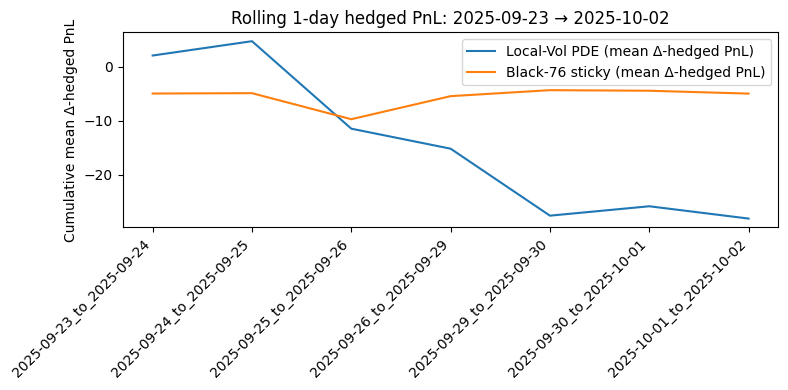

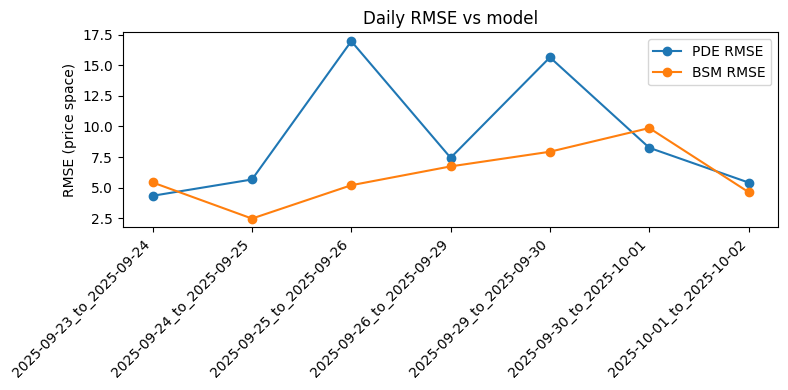

In [68]:
# Run the backtest
res, daily = run_backtest("2025-09-23", "2025-10-02")